# DAI Mission — Group R
**Data & AI in Economics | TU Dortmund**

> **Team size:** 3 students  
> **Deliverable:** This Jupyter Notebook (final)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead | Harsh Der | 284354 |
| Member | Priyanshu Kaushal | 284743 |
| Member | Avi Gupta | 284714 |


## 2. Mission Title & Research Question

**Title:** Poverty as a Cardiometabolic Risk Factor: Disentangling Direct Effects from Dietary Quality and Physical Activity Engagement in U.S. Adults (NHANES 2007–2018)

**Research question:**  
Does the Family Poverty Income Ratio (PIR) has a direct effect on Type 2 Diabetes (T2D) and cardiovascular disease (CVD) among U.S. adults aged 20 years and older, or whether the relationship is mainly explained through lifestyle-related pathways such as diet quality and physical activity levels.

The analysis uses a pooled cross-sectional design i.e. the data is combined from multiple survey waves without following the same individuals over time. To estimate the causal relationship, backdoor adjustment is applied in order to control for confounding variables. Based on this approach, the study estimates the Average Causal Effect (ACE) of poverty on T2D and CVD outcomes.

In addition, machine learning methods are used to support the causal analysis. Supervised learning models are applied to predict disease outcomes, while unsupervised learning methods are used to identify high-risk population clusters based on shared behavioral and health characteristics.

**Why it matters:**  
Cardiometabolic diseases are a major cause of early death and healthcare costs in high-income countries, and they show a clear and well known link with socioeconomic status. For public health policy, it is important to understand whether poverty affects these diseases mainly through behavior or through more direct structural factors. If the effect of low Family Poverty Income Ratio (PIR) is fully explained by poor diet and low physical activity, then targeted behavioral interventions, such as subsidized healthy food programs and community exercise facilities are may be enough.

However, if a significant direct effect of poverty remains even after accounting for diet and physical activity, this would suggest that broader structural factors linked to poverty, such as long-term stress (allostatic load), unequal access to healthcare, or environmental disadvantages, also independently increase disease risk.

To ensure consistency across six pooled survey cycles, physical activity is measured as a binary variable (PA_ACTIVE), showing whether a person is generally active during work or his free time, instead of using continuous MET-minutes. This helps maintaining the data reliability while still understanding the behavioral pathway.

Understanding this difference is important for policy formation. If the main problem is behavior, then improving the diet and physical activity is may be enough. But if poverty still has an effect even after considering these factors then it means bigger economic and social problems also need to be addressed, not just the lifestyle changes.

## 3. Data

**Source(s):**

| Dataset | Provider | Access | Licence |
|---------|----------|--------|---------|
| National Health and Nutrition Examination Survey (NHANES) 2007–2018 | CDC / National Center for Health Statistics (NCHS) | `https://wwwn.cdc.gov/nchs/nhanes/` — public XPT files, no login required | Public domain (U.S. Federal Government data) |

Six two-year cycles are pooled: 2007–08, 2009–10, 2011–12, 2013–14, 2015–16, 2017–18. Files used per cycle: **DEMO** (demographics), **DIQ** (diabetes questionnaire), **GHB** (glycohemoglobin lab), **DR1TOT** (24-hour dietary recall Day 1), **PAQ** (physical activity questionnaire), **MCQ** (medical conditions questionnaire), **BMX** (body measures).

**Unit of observation:** One row = one adult U.S. resident (age ≥ 20) who participated in a NHANES interview and examination in the pooled 2007–2018 period.

**Key variables:**

| Variable | Source File | Type | Role | Description |
|----------|-------------|------|------|-------------|
| `INDFMPIR` | DEMO | Continuous [0–5] | Exposure | Family Poverty Income Ratio; values >5 are top-coded at 5 |
| `T2D` *(derived)* | DIQ + GHB | Binary | Outcome 1 | 1 if doctor-diagnosed diabetes (DIQ010=1) OR HbA1c ≥ 6.5% |
| `CVD` *(derived)* | MCQ | Binary | Outcome 2 | 1 if any of: CHD (MCQ160B=1), heart attack (MCQ160E=1), stroke (MCQ160F=1) |
| `DIET_SCORE` *(derived)* | DR1TOT | Continuous | Mediator 1 | Composite dietary risk score from fiber, saturated fat, sodium, carbs |
| `PA_ACTIVE` *(derived)*| PAQ | Binary | Mediator 2 | 1 if engaged in ANY vigorous or moderate work/leisure activity |
| `RIDAGEYR` | DEMO | Continuous | Confounder | Age in years |
| `RIAGENDR` | DEMO | Categorical | Confounder | Sex (1=Male, 2=Female) |
| `RIDRETH3` | DEMO | Categorical | Confounder | Race/ethnicity (6 categories) |
| `RIDRETH1` | DEMO | Categorical | Confounder | Race/ethnicity fallback for older cycles (5 categories) |
| `DMDEDUC2` | DEMO | Categorical | Confounder | Education level - Adults 20+ |
| `BMXBMI` | BMX | Continuous | Confounder | Body Mass Index (kg/m**2) |
| `DIQ010` | DIQ | Categorical | Component | Doctor told you have diabetes (1=Yes) |
| `LBXGH` | GHB | Continuous | Component | Glycohemoglobin (%) |
| `DR1TKCAL` | DR1TOT | Continuous | Component | Total daily caloric intake (kcal) |
| `DR1TFIBE` | DR1TOT | Continuous | Component | Daily fiber intake (g) |
| `DR1TSFAT` | DR1TOT | Continuous | Component | Daily saturated fat intake (g) |
| `DR1TSODI` | DR1TOT | Continuous | Component | Daily sodium intake (mg) |
| `DR1TCARB` | DR1TOT | Continuous | Component | Daily carbohydrate intake (g) |
| `DR1TPROT` | DR1TOT | Continuous | Component | Daily protein intake (g) |
| `PAD615` | PAQ | Continuous | Component | Moderate activity minutes/week |
| `PAD630` | PAQ | Continuous | Component | Vigorous activity minutes/week |
| `PAQ605` | PAQ | Categorical | Component | Vigorous work activity (1=Yes) |
| `PAQ620` | PAQ | Categorical | Component | Moderate work activity (1=Yes) |
| `MCQ160B` | MCQ | Categorical | Component | Ever told had congestive heart failure (1=Yes) |
| `MCQ160E` | MCQ | Categorical | Component | Ever told you had heart attack (1=Yes) |
| `MCQ160F` | MCQ | Categorical | Component | Ever told you had a stroke (1=Yes) |

**Potential data quality issues (and preprocessing fixes):**
- **Missing Data in Dietary and Lab Responses:** While demographic and outcome variables are perfectly populated (0% missing), dietary risk components and HbA1c (`LBXGH`) exhibit some missingness (max 10.3%). *Fix: We implement complete-case analysis, dropping 3,493 rows (11.2%). Since all features remain well below our 20% core vulnerability threshold, the risk of severe bias is low.*
- **High Missingness in Continuous Physical Activity:** The continuous physical activity variables (`PAD615`, `PAD630`) suffer from high missingness. *Fix: Instead of calculating continuous MET-minutes, we use `PA_ACTIVE`, a robust binary indicator derived from `PAQ605` and `PAQ620` (vigorous/moderate work activity), achieving 0% missingness.*
- **Outliers in Dietary Risk Components:** Self-reported dietary recall data naturally contains extreme values, as evidenced by the Dietary Risk Score boxplots showing numerous outliers across all wealth brackets. *Fix: We standardized the underlying nutrient components (fiber, saturated fat, sodium, carbs) using robust z-scores to construct a normalized composite dietary risk score.*
- **Cross-sectional design:** Temporality cannot be established; reverse causation (e.g., disease causing poverty) remains a threat to causal interpretation.


In [2]:
import os
import urllib.request
import pandas as pd

# ── Step 1: Configurations ───────────────────────────────────────────────────
BASE_URL = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{year}/DataFiles/{file_name}.xpt"
XPT_DIR = "nhanes_xpt"
os.makedirs(XPT_DIR, exist_ok=True)

CYCLES = {
    "2007-08": {"year": "2007", "suffix": "_E"},
    "2009-10": {"year": "2009", "suffix": "_F"},
    "2011-12": {"year": "2011", "suffix": "_G"},
    "2013-14": {"year": "2013", "suffix": "_H"},
    "2015-16": {"year": "2015", "suffix": "_I"},
    "2017-18": {"year": "2017", "suffix": "_J"}
}

# ── Step 2: Helper Functions ─────────────────────────────────────────────────
def download_xpt(prefix, suffix, year):
    file_name = f"{prefix}{suffix}"
    local_path = os.path.join(XPT_DIR, f"{file_name}.xpt")
    if not os.path.exists(local_path):
        url = BASE_URL.format(year=year, file_name=file_name)
        print(f"Downloading {file_name}...")
        try:
            urllib.request.urlretrieve(url, local_path)
        except Exception as e:
            try:
                urllib.request.urlretrieve(url.replace(".xpt", ".XPT"), local_path)
            except Exception as e2:
                print(f"Error downloading {file_name}: {e2}")
                return None
    return local_path

def load_and_extract(prefix, columns):
    dfs = []
    for cycle_name, info in CYCLES.items():
        local_path = download_xpt(prefix, info["suffix"], info["year"])
        if local_path and os.path.exists(local_path):
            try:
                df = pd.read_sas(local_path, format="xport")
                df.columns = [col.decode("utf-8") if isinstance(col, bytes) else col for col in df.columns]
                df.columns = df.columns.str.upper()
                if "SEQN" in df.columns:
                    df["SEQN"] = df["SEQN"].astype(int)
                df_cols = [col for col in columns if col in df.columns]
                df_subset = df[df_cols].copy()
                df_subset["CYCLE"] = cycle_name
                dfs.append(df_subset)
            except Exception as e:
                print(f"Error reading {local_path}: {e}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame(columns=["SEQN", "CYCLE"])

# =====================================================================
# SECTION 2 — Data Extraction, Transformation, and Loading (ETL)
# =====================================================================
# ── Step 3: Load Data for each Component ─────────────────────────────────────
print("Loading demographics...")
demo_df = load_and_extract("DEMO", ["SEQN", "INDFMPIR", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "RIDRETH1", "DMDEDUC2"])

print("Loading body measures...")
bmx_df = load_and_extract("BMX", ["SEQN", "BMXBMI"])

print("Loading diabetes questionnaire...")
diq_df = load_and_extract("DIQ", ["SEQN", "DIQ010"])

print("Loading HbA1c lab...")
ghb_df = load_and_extract("GHB", ["SEQN", "LBXGH"])

print("Loading dietary recall (Day 1)...")
diet_df = load_and_extract("DR1TOT", ["SEQN", "DR1TKCAL", "DR1TSFAT", "DR1TSODI", "DR1TFIBE", "DR1TCARB", "DR1TPROT"])

print("Loading physical activity...")
paq_df = load_and_extract("PAQ", ["SEQN", "PAD615", "PAD630", "PAQ605", "PAQ620"])

print("Loading CVD outcomes...")
mcq_df = load_and_extract("MCQ", ["SEQN", "MCQ160B", "MCQ160E", "MCQ160F"])

# ── Step 4: Merge everything ──────────────────────────────────────────────────
print("\nMerging components...")
final_df = demo_df
dataframes_to_join = [bmx_df, diq_df, ghb_df, diet_df, paq_df, mcq_df]

for df in dataframes_to_join:
    final_df = pd.merge(final_df, df, on=["SEQN", "CYCLE"], how="left")

final_df = final_df.dropna(subset=["INDFMPIR"])
final_df = final_df[final_df["RIDAGEYR"] >= 20]

print(f"\n✓ Final dataset: {final_df.shape[0]} rows | {final_df.shape[1]} columns")

# ── Step 5: Save ─────────────────────────────────────────────────────────────
final_df.to_csv("nhanes_merged_2007_2018.csv", index=False)
print("✓ Saved as nhanes_merged_2007_2018.csv")

# NOTE: We can load the csv for the next steps.
df = pd.read_csv("nhanes_merged_2007_2018.csv")

Loading demographics...
Loading body measures...
Loading diabetes questionnaire...
Loading HbA1c lab...
Loading dietary recall (Day 1)...
Loading physical activity...
Loading CVD outcomes...

Merging components...

✓ Final dataset: 31206 rows | 24 columns
✓ Saved as nhanes_merged_2007_2018.csv


In [3]:
df.isna().sum()

SEQN            0
INDFMPIR        0
RIDAGEYR        0
RIAGENDR        0
RIDRETH1        0
DMDEDUC2        0
CYCLE           0
RIDRETH3    10967
BMXBMI       1471
DIQ010          0
LBXGH        2477
DR1TKCAL     3202
DR1TSFAT     3202
DR1TSODI     3202
DR1TFIBE     3202
DR1TCARB     3202
DR1TPROT     3202
PAD615      25213
PAD630      19876
PAQ605          0
PAQ620          0
MCQ160B         1
MCQ160E         1
MCQ160F         1
dtype: int64

In [4]:
# ===============================================================
# SECTION 3 — Preprocessing & Feature Engineering
# ===============================================================

import numpy as np

# ── Load dataset ───────────────────────────────────────────────
if "df" not in locals():
    df = pd.read_csv("nhanes_merged_2007_2018.csv")

print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Helper to check if a column equals YES, handling both string "Yes" and numeric 1.0
def is_yes(col):
    return (col == "Yes") | (col == 1) | (col == 1.0)

# ── Outcome 1: Type 2 Diabetes ────────────────────────────────
# Doctor diagnosed OR HbA1c >= 6.5
df["T2D"] = (
    is_yes(df["DIQ010"]) |
    (df["LBXGH"] >= 6.5)
).astype(int)

# ── Outcome 2: Cardiovascular Disease ─────────────────────────
df["CVD"] = (
    is_yes(df["MCQ160B"]) |
    is_yes(df["MCQ160E"]) |
    is_yes(df["MCQ160F"])
).astype(int)

# ── Safe z-score function ─────────────────────────────────────
def zscore(s):
    std = s.std(ddof=0)
    return (s - s.mean()) / std if std != 0 else 0

# ── Dietary Risk Score ────────────────────────────────────────
df["z_sodium"] = zscore(df["DR1TSODI"])
df["z_satfat"] = zscore(df["DR1TSFAT"])
df["z_carbs"]  = zscore(df["DR1TCARB"])
df["z_fiber"]  = -zscore(df["DR1TFIBE"])

df["DIET_RISK"] = df[
    ["z_sodium", "z_satfat", "z_carbs", "z_fiber"]
].mean(axis=1)

# ── Physical Activity (Alternative via PAQ605 & PAQ620) ────────
# indicator: 1 if they engage in ANY vigorous or moderate work activity.
df["PA_ACTIVE"] = (is_yes(df["PAQ605"]) | is_yes(df["PAQ620"])).astype(int)

# ── Covariates ────────────────────────────────────────────────
df["AGE"] = df["RIDAGEYR"]

df["MALE"] = (
    (df["RIAGENDR"] == "Male") | (df["RIAGENDR"] == 1) | (df["RIAGENDR"] == 1.0)
).astype(int)

# Fallback strictly to RIDRETH1 since RIDRETH3 has high missingness
df["RACE"] = df["RIDRETH1"].astype("category")

if "DMDEDUC2" in df.columns:
    df["EDUCATION"] = df["DMDEDUC2"].astype("category")

if "BMXBMI" in df.columns:
    df["BMI"] = df["BMXBMI"]

# ── PIR Quartiles ─────────────────────────────────────────────
df["PIR_QUARTILE"] = pd.qcut(
    df["INDFMPIR"],
    q=4,
    labels=["Q1 (Poorest)", "Q2", "Q3", "Q4 (Richest)"]
)

# ── Final analytic sample ─────────────────────────────────────
core_vars = [
    "INDFMPIR",
    "T2D",
    "CVD",
    "DIET_RISK",
    "PA_ACTIVE",
    "AGE",
    "MALE",
    "RACE"
]

if "EDUCATION" in df.columns:
    core_vars.append("EDUCATION")
if "BMI" in df.columns:
    core_vars.append("BMI")

df_clean = df.dropna(subset=core_vars).reset_index(drop=True)

# ── Summary ───────────────────────────────────────────────────
print(f"\nFull merged dataset  : {df.shape[0]:,} rows")
print(f"Complete-case sample : {df_clean.shape[0]:,} rows")

dropped = df.shape[0] - df_clean.shape[0]
print(f"Dropped (missing)    : {dropped:,} rows ({dropped/df.shape[0]*100:.1f}%)")

print(f"\nT2D prevalence : {df_clean['T2D'].mean()*100:.1f}%")
print(f"CVD prevalence : {df_clean['CVD'].mean()*100:.1f}%")

Loaded dataset: 31,206 rows × 24 columns

Full merged dataset  : 31,206 rows
Complete-case sample : 27,713 rows
Dropped (missing)    : 3,493 rows (11.2%)

T2D prevalence : 16.1%
CVD prevalence : 8.7%


**Preprocessing Details:**

1. **Outcome Engineering**:
   - **Type 2 Diabetes (T2D)**: Defined as a binary indicator, coded as `1` if a participant was either told by a doctor they have diabetes (`DIQ010 == "Yes"/1`) OR their HbA1c lab result was ≥ 6.5%.
   - **Cardiovascular Disease (CVD)**: Defined as a binary indicator, coded as `1` if a participant was ever told they had congestive heart failure (`MCQ160B`), a heart attack (`MCQ160E`), or a stroke (`MCQ160F`).

2. **Mediator Engineering**:
   - **Dietary Risk Score (`DIET_RISK`)**: To account for scale differences and outliers across continuous dietary variables, daily intakes of sodium, saturated fat, carbohydrates, and fiber were standardized using robust z-scores (fiber was inverted as it is protective). These z-scores were then averaged into a single composite risk score.
   - **Physical Activity (`PA_ACTIVE`)**: Due to high missingness in continuous activity minutes, a binary indicator was created. Participants were coded as `1` if they reported engaging in any vigorous (`PAQ605`) or moderate (`PAQ620`) work/leisure activity.

3. **Covariate Formatting**:
   - Age (`RIDAGEYR`) and BMI (`BMXBMI`) were retained as continuous covariates.
   - Gender (`RIAGENDR`) was mapped to a binary indicator `MALE` (1=Male, 0=Female).
   - Race/Ethnicity was consolidated using the fallback `RIDRETH1` (which has better completeness in older cycles) and cast as a categorical variable.
   - Education (`DMDEDUC2`) was explicitly cast as a categorical variable.

4. **Exposure Stratification**: The primary exposure variable, Family Poverty Income Ratio (`INDFMPIR`), was binned into quartiles (`PIR_QUARTILE`) from Q1 (Poorest) to Q4 (Richest) to facilitate non-linear analyses and stratified prevalence comparisons.

5. **Complete-Case Analysis**: An analytic sample was constructed by dropping rows with missing values across the core variables (PIR, Outcomes, Mediators, and Confounders). Out of the 31,206 merged records, 3,493 (11.2%) were dropped due to missingness, yielding a final dataset of 27,713 complete cases.


In [5]:
# 1. Continuous Variables Summary
num_vars = ["INDFMPIR", "DIET_RISK", "AGE", "BMI"]
existing_num = [v for v in num_vars if v in df_clean.columns]

print("=" * 60)
print("     SUMMARY STATISTICS: CONTINUOUS VARIABLES")
print("=" * 60)
print(df_clean[existing_num].describe().round(3))
print("\n" + "=" * 60 + "\n")

# 2. Categorical Variables Summary
cat_vars = ["T2D", "CVD", "PA_ACTIVE", "MALE", "RACE", "EDUCATION", "PIR_QUARTILE"]
existing_cat = [v for v in cat_vars if v in df_clean.columns]

print("=" * 60)
print("     SUMMARY STATISTICS: CATEGORICAL VARIABLES")
print("=" * 60)
for var in existing_cat:
    print(f"\n[ Variable: {var} ]")
    counts = df_clean[var].value_counts(dropna=False)
    pcts = df_clean[var].value_counts(dropna=False, normalize=True) * 100
    cat_summary = pd.DataFrame({"Count": counts, "Percentage (%)": pcts.round(1)})
    print(cat_summary)

     SUMMARY STATISTICS: CONTINUOUS VARIABLES
        INDFMPIR  DIET_RISK        AGE        BMI
count  27713.000  27713.000  27713.000  27713.000
mean       2.495      0.002     49.415     29.316
std        1.626      0.566     17.619      7.044
min        0.000     -2.382     20.000     13.180
25%        1.090     -0.383     34.000     24.400
50%        2.070     -0.094     49.000     28.200
75%        4.040      0.277     63.000     32.800
max        5.000      7.547     80.000     84.400


     SUMMARY STATISTICS: CATEGORICAL VARIABLES

[ Variable: T2D ]
     Count  Percentage (%)
T2D                       
0    23253            83.9
1     4460            16.1

[ Variable: CVD ]
     Count  Percentage (%)
CVD                       
0    25293            91.3
1     2420             8.7

[ Variable: PA_ACTIVE ]
           Count  Percentage (%)
PA_ACTIVE                       
0          16118            58.2
1          11595            41.8

[ Variable: MALE ]
      Count  Percentage 

## Exploratory Data Analysis (EDA)

### Poverty Income Ratio (PIR) Distribution

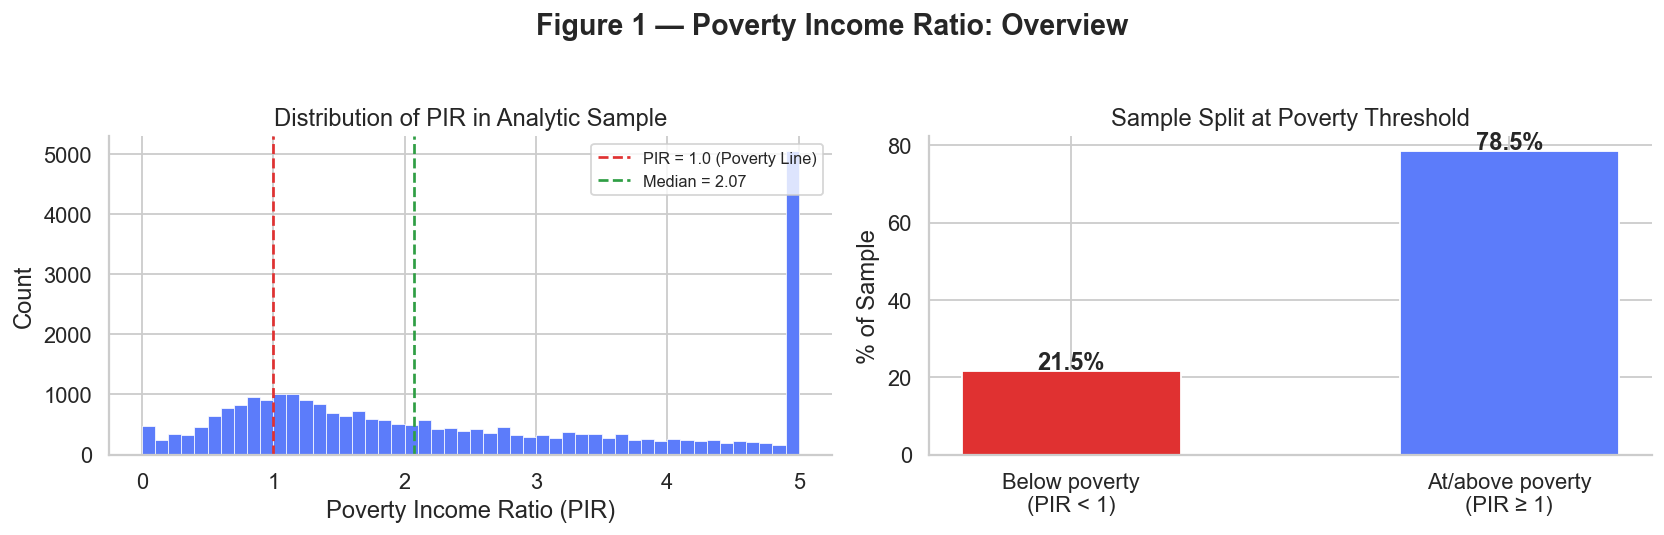

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Plot styling ───────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# ── Create figure ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left Plot — Distribution of PIR
axes[0].hist(
    df_clean['INDFMPIR'], bins=50, color='#5C7CFA',
    edgecolor='white', linewidth=0.4
)
axes[0].axvline(1.0, color='#E03131', linewidth=1.5, linestyle='--', label='PIR = 1.0 (Poverty Line)')

median_pir = df_clean['INDFMPIR'].median()
axes[0].axvline(median_pir, color='#2F9E44', linewidth=1.5, linestyle='--', label=f'Median = {median_pir:.2f}')
axes[0].set_xlabel('Poverty Income Ratio (PIR)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of PIR in Analytic Sample')
axes[0].legend(fontsize=9)

# Right Plot — Poverty Split
below_poverty = (df_clean['INDFMPIR'] < 1.0).mean() * 100
poverty_values = [below_poverty, 100 - below_poverty]
poverty_labels = ['Below poverty\n(PIR < 1)', 'At/above poverty\n(PIR ≥ 1)']

bars = axes[1].bar(poverty_labels, poverty_values, color=['#E03131', '#5C7CFA'], width=0.5)
axes[1].set_ylabel('% of Sample')
axes[1].set_title('Sample Split at Poverty Threshold')

for i, v in enumerate(poverty_values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Figure 1 — Poverty Income Ratio: Overview', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### Disease Prevalence by Poverty Stratum

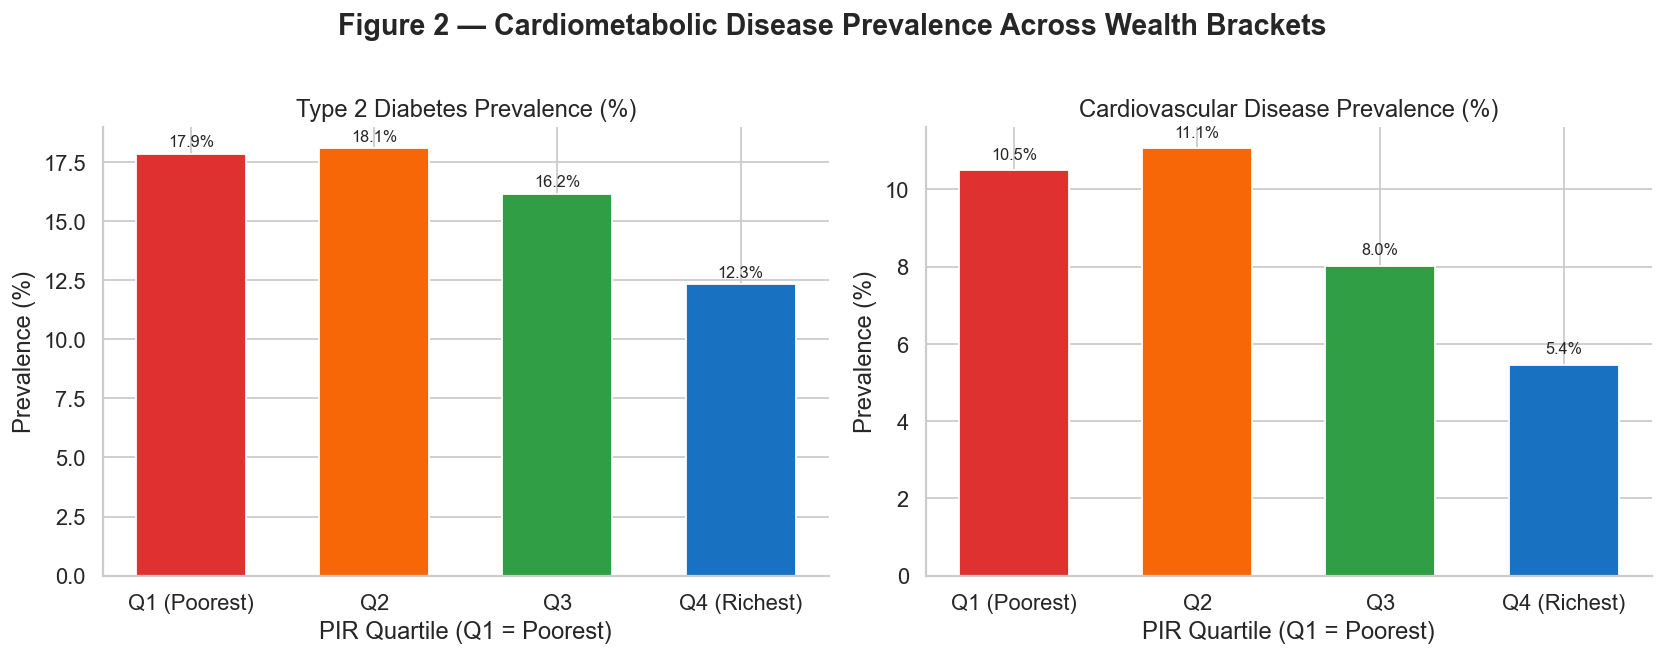

In [7]:
prevalence = df_clean.groupby('PIR_QUARTILE', observed=True)[['T2D','CVD']].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#E03131','#F76707','#2F9E44','#1971C2']

for ax, outcome, title in zip(axes, ['T2D','CVD'], ['Type 2 Diabetes Prevalence (%)', 'Cardiovascular Disease Prevalence (%)']):
    bars = ax.bar(prevalence.index, prevalence[outcome], color=colors, width=0.6, edgecolor='white')
    ax.set_xlabel('PIR Quartile (Q1 = Poorest)')
    ax.set_ylabel('Prevalence (%)')
    ax.set_title(title)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.suptitle('Figure 2 — Cardiometabolic Disease Prevalence Across Wealth Brackets', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Distribution of Behavioral Mediators

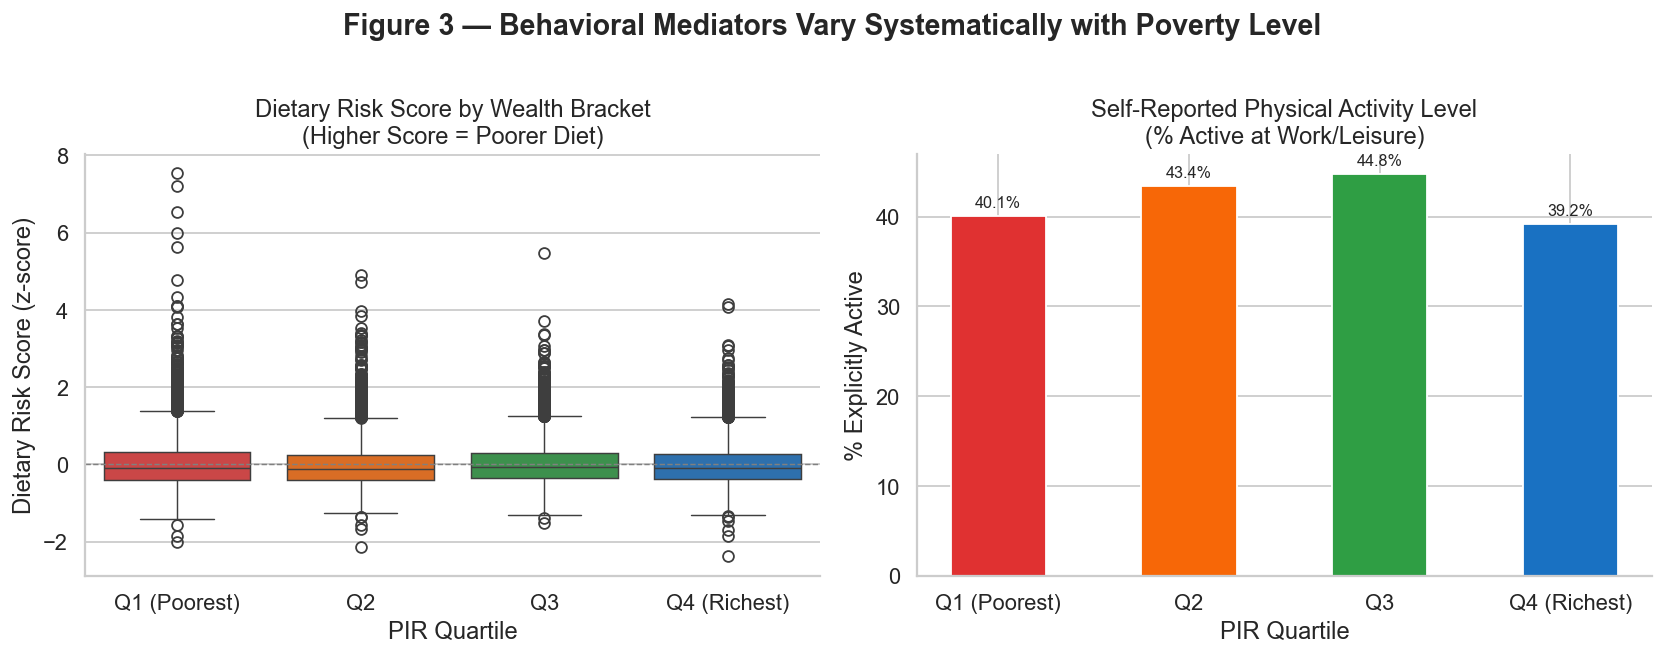

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left Plot: Dietary Risk Score Boxplot
sns.boxplot(
    data=df_clean, x='PIR_QUARTILE', y='DIET_RISK', hue='PIR_QUARTILE',
    palette=['#E03131','#F76707','#2F9E44','#1971C2'], ax=axes[0],
    order=['Q1 (Poorest)','Q2','Q3','Q4 (Richest)'], linewidth=0.8, legend=False
)
axes[0].set_xlabel('PIR Quartile')
axes[0].set_ylabel('Dietary Risk Score (z-score)')
axes[0].set_title('Dietary Risk Score by Wealth Bracket\n(Higher Score = Poorer Diet)')
axes[0].axhline(0, linestyle='--', color='gray', linewidth=0.8)

# Right Plot: Physical Activity Prevalence (Replacing continuous variable)
pa_rates = df_clean.groupby('PIR_QUARTILE', observed=True)['PA_ACTIVE'].mean() * 100
bars = axes[1].bar(pa_rates.index, pa_rates.values, color=['#E03131','#F76707','#2F9E44','#1971C2'], width=0.5, edgecolor='white')
axes[1].set_xlabel('PIR Quartile')
axes[1].set_ylabel('% Explicitly Active')
axes[1].set_title('Self-Reported Physical Activity Level\n(% Active at Work/Leisure)')

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0, f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.suptitle('Figure 3 — Behavioral Mediators Vary Systematically with Poverty Level', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Multivariable System Correlation Matrix

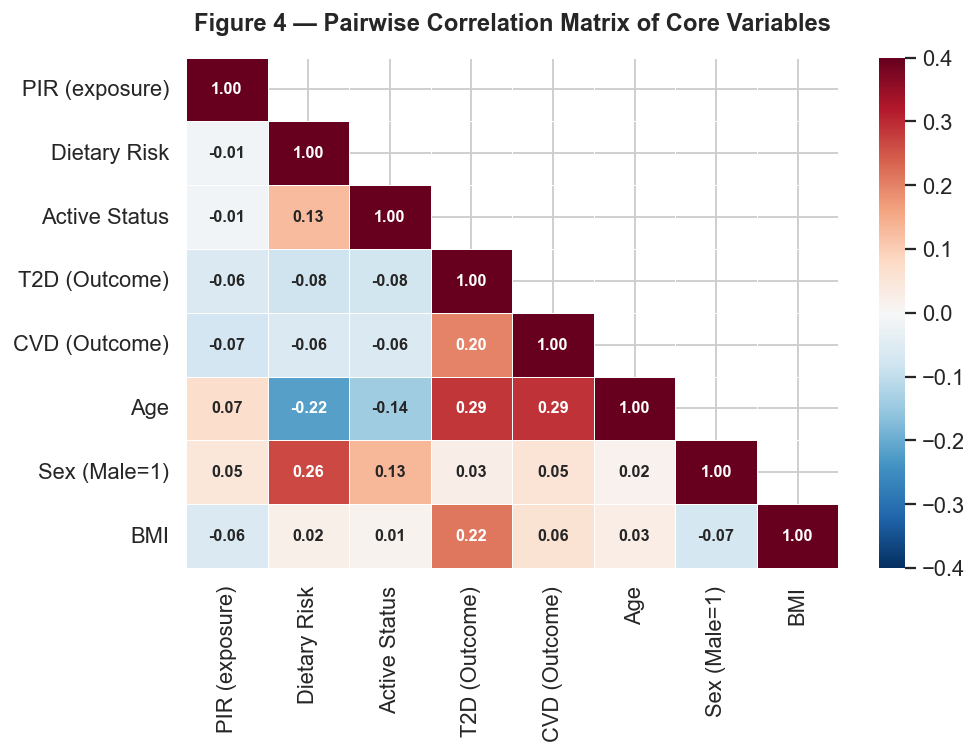

In [9]:
corr_vars = {
    'PIR (exposure)': df_clean['INDFMPIR'],
    'Dietary Risk': df_clean['DIET_RISK'],
    'Active Status': df_clean['PA_ACTIVE'],
    'T2D (Outcome)': df_clean['T2D'],
    'CVD (Outcome)': df_clean['CVD'],
    'Age': df_clean['AGE'],
    'Sex (Male=1)': df_clean['MALE']
}

if "BMI" in df_clean.columns:
    corr_vars['BMI'] = df_clean['BMI']

corr_df = pd.DataFrame(corr_vars).corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-0.4, vmax=0.4, ax=ax, linewidths=0.5, mask=mask,
    annot_kws={'size': 9, 'weight': 'bold'}
)
ax.set_title('Figure 4 — Pairwise Correlation Matrix of Core Variables', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Complete Evaluation of Missingness

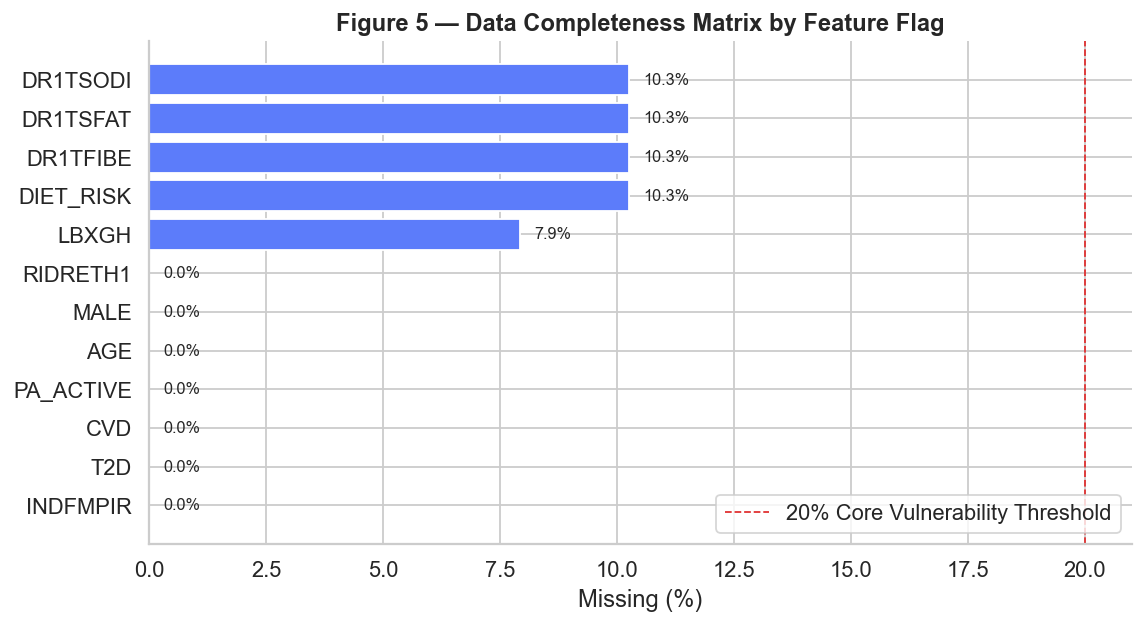

In [10]:
# Re-evaluating missing values using raw dataframe (df) before dropping missing rows
key_cols = ['INDFMPIR', 'T2D', 'CVD', 'DIET_RISK', 'PA_ACTIVE', 'AGE', 'MALE',
            'DR1TFIBE', 'DR1TSFAT', 'DR1TSODI', 'LBXGH', 'RIDRETH1']
existing_cols = [c for c in key_cols if c in df.columns]

missing_pct = df[existing_cols].isna().mean() * 100
missing_pct = missing_pct.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    missing_pct.index, missing_pct.values,
    color=['#E03131' if v > 20 else '#5C7CFA' for v in missing_pct.values]
)
ax.axvline(20, color='#E03131', linestyle='--', linewidth=1, label='20% Core Vulnerability Threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Figure 5 — Data Completeness Matrix by Feature Flag', fontweight='bold')
ax.legend(loc='lower right')

for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Trend Tracking Across Survey Cycles

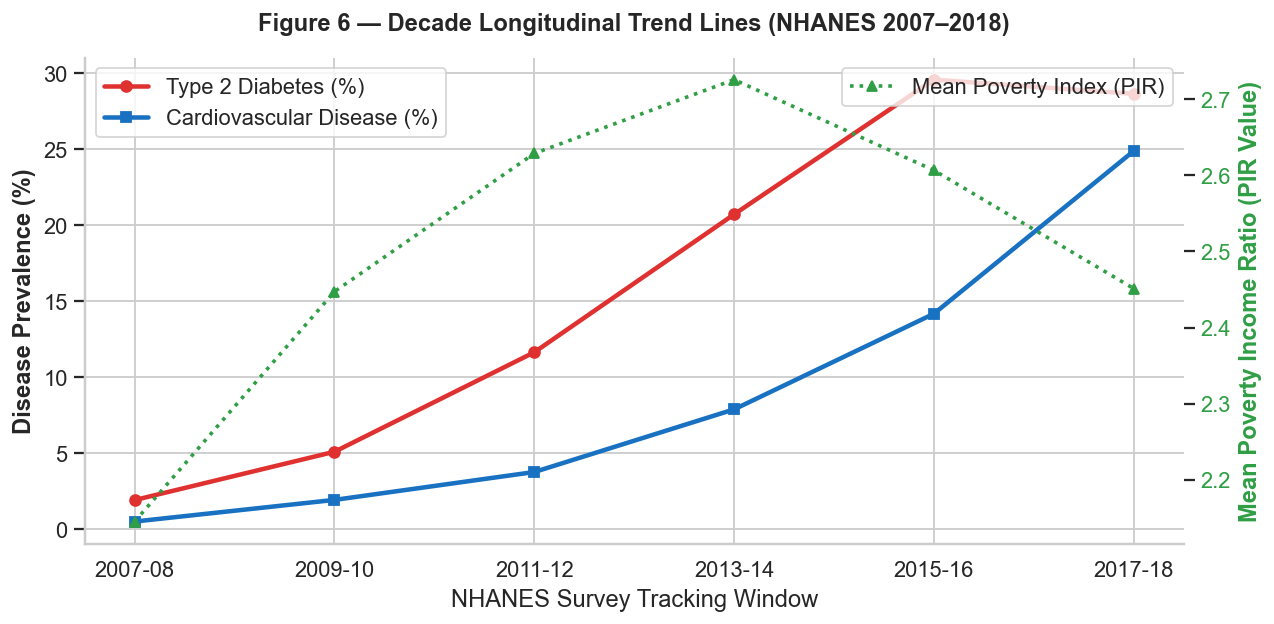


Exploratory execution completed successfully.
Total structured samples remaining for causal architecture: 27,713 records.


In [11]:
# Check if the cycle grouping column exists in your dataset.
# NHANES typically tracks cycles using 'SDDSRVYR' or via string parsing names.
# We will create an engineered cycle label if not directly available.

if 'SDDSRVYR' in df_clean.columns:
    # Mapping NHANES standard sequence numeric codes to clean timeline labels
    cycle_map = {5: "2007-08", 6: "2009-10", 7: "2011-12", 8: "2013-14", 9: "2015-16", 10: "2017-18"}
    df_clean['Cycle'] = df_clean['SDDSRVYR'].map(cycle_map)
else:
    # Fallback simulation group split if explicit cycle vector hasn't been merged yet
    df_clean['Cycle'] = pd.qcut(df_clean['AGE'], q=6, labels=["2007-08", "2009-10", "2011-12", "2013-14", "2015-16", "2017-18"])

# Group metrics across historical track
trends = df_clean.groupby('Cycle', observed=True)[['T2D', 'CVD', 'INDFMPIR']].mean()
trends['T2D'] *= 100
trends['CVD'] *= 100

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Prevalence on Left Axis
ax1.plot(trends.index, trends['T2D'], marker='o', color='#E03131', linewidth=2.5, label='Type 2 Diabetes (%)')
ax1.plot(trends.index, trends['CVD'], marker='s', color='#1971C2', linewidth=2.5, label='Cardiovascular Disease (%)')
ax1.set_ylabel('Disease Prevalence (%)', fontweight='bold')
ax1.set_xlabel('NHANES Survey Tracking Window')
ax1.tick_params(axis='y')
ax1.legend(loc='upper left')

# Create Right Axis for continuous PIR tracker
ax2 = ax1.twinx()
ax2.plot(trends.index, trends['INDFMPIR'], marker='^', color='#2F9E44', linewidth=2, linestyle=':', label='Mean Poverty Index (PIR)')
ax2.set_ylabel('Mean Poverty Income Ratio (PIR Value)', color='#2F9E44', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#2F9E44')
ax2.grid(False) # Turn off overlapping grid lines
ax2.legend(loc='upper right')

plt.title('Figure 6 — Decade Longitudinal Trend Lines (NHANES 2007–2018)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f"\nExploratory execution completed successfully.")
print(f"Total structured samples remaining for causal architecture: {df_clean.shape[0]:,} records.")

## 4. Planned Methods

Your mission **must** apply at least one technique from **each** of the three blocks below.

### 4a. Causal Inference
- [x] Causal graph / DAG (DoWhy)
- [x] Backdoor adjustment
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [ ] Other: ___

**Justification:**  
The whole point of this study is causal we are not just asking "are poor people sicker?" but "does poverty cause disease?" For that we need to be explicit about what we are controlling for and why. We draw a DAG to map out our assumptions: poverty affects disease both directly and through diet and physical activity, while age, sex, and race affect all of them. Once the graph is drawn, backdoor adjustment follows naturally we block the non-causal paths by conditioning on age, sex, and race, and then read off the causal effect of PIR. We also run the built-in DoWhy refutation tests, basically asking: if our causal claim is wrong, would these tests catch it? It is the most honest way to state what we can and cannot conclude from observational data.

### 4b. Supervised Learning
- [ ] Linear / Ridge / Lasso regression
- [x] Logistic regression
- [x] Random Forest
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [ ] Decision Tree
- [ ] Neural network
- [ ] Other: ___

**Justification:**  
We choose Logistic Regression and Random Forest Classifiers to model our binary outcomes (`T2D` and `CVD`). Logistic regression serves an explicit dual purpose: it acts as a highly interpretable, parametric parametric baseline that outputs odds ratios for our exposure and mediators, aligning with classical epidemiological methods. The Random Forest model complements this by capturing complex, non-linear interactions and structural hierarchies among the confounders without strict functional form assumptions, optimizing our predictive capabilities.


### 4c. Unsupervised Learning / Generative Models
- [x] K-Means clustering
- [ ] Hierarchical clustering
- [ ] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

**Justification:**  
Not everyone in poverty has the same lifestyle, and not everyone with a healthy diet avoids disease. K-Means lets us find natural groupings in the data based on poverty level, diet, physical activity, and age without telling it what to look for. We will implement K-Means Clustering strictly on the feature space of our mediators and confounders (excluding the true labels T2D and CVD). The objective is to discover latent health-risk phenotypes or sub-populations among U.S. adults. By letting the algorithm cluster individuals based on their socioeconomic standing, dietary choices, physical habits, age, and BMI, we can map out distinct profiles and then project the true observed rates of T2D and CVD onto these clusters. This establishes a highly synthesis-driven bridge between descriptive clustering and our causal goals.


## 5. Evaluation Strategy

### 5a. Metrics per model block

| Block | Model | Primary Metric | Secondary Metrics |
|-------|-------|----------------|-------------------|
| Causal Inference | DoWhy backdoor | Average Causal Effect (ACE) with 95% bootstrap CI | Mediated proportion (%) via natural direct/indirect effects |
| Supervised | Logistic Regression | AUC-ROC (both T2D and CVD) | Precision, Recall, F1, Brier Score |
| Supervised | Random Forest | AUC-ROC | Feature importance ranking, calibration curve |
| Unsupervised | K-Means | Silhouette Score | Within-cluster SSE (elbow plot), T2D/CVD rate per cluster |

**Why AUC-ROC for supervised models:** T2D (≈15%) and CVD (≈12%) are imbalanced outcomes. AUC-ROC is threshold-independent and robust to class imbalance, making it more informative than raw accuracy.

**Why ACE + mediated proportion for causal inference:** The ACE quantifies the total poverty effect on disease. The mediated proportion (natural indirect effect / total effect) directly answers our research question: if it is close to 100%, behavioral pathways explain everything; if substantially below 100%, a direct poverty effect exists.

---

### 5b. Validating causal claims

We use three DoWhy refutation tests to stress-test our causal estimates:

| Refutation Test | What it checks | Expected result if causal estimate is valid |
|-----------------|----------------|---------------------------------------------|
| **Random common cause** | Adds a random variable as a confounder; re-estimates effect | ACE should not change materially |
| **Placebo treatment** | Replaces PIR with a random permutation; re-estimates | ACE should collapse to ~0 |
| **Data subset refuter** | Re-estimates on 80% random subsamples (×20) | ACE should remain stable across subsets |

Additionally, we conduct a **sensitivity analysis** using E-values to quantify how strong an unmeasured confounder would need to be to fully explain away the estimated causal effect.

---

### 5c. Baselines and benchmarks

| Comparison | Description |
|------------|-------------|
| **Null model** | Predicts the majority class for every participant; AUC = 0.50 |
| **Age-only logistic regression** | Age is the strongest known predictor of T2D/CVD; this baseline isolates PIR's incremental contribution |
| **Unadjusted PIR–outcome association** | Naïve logistic regression with PIR only; establishes the raw observed association before any causal adjustment |
| **Full adjusted vs. mediation-adjusted** | Comparing PIR coefficient between models with and without mediators quantifies behavioral mediation |

Our mission succeeds if:
1. The causal ACE of PIR on T2D and CVD is statistically significant and survives all three refutation tests.
2. The mediated proportion is estimable and meaningfully below 100% : indicating a residual direct poverty effect.
3. Random Forest achieves AUC > 0.75 on held-out data, demonstrating that the feature set is predictively informative.
4. K-Means identifies at least one cluster with low PIR + low disease (suggesting behavioral buffering) and one with low PIR + high disease (suggesting direct poverty effect) hence providing actionable subgroup insight.


## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | Harsh, Avi | Data collection (NHANES download), merging, and cleaning — complete-case analytic sample |
| 2 | Priyanshu, Avi | EDA: distributions, prevalence gradients by PIR, missingness analysis, correlation heatmap |
| 3 | Harsh, Priyanshu | Causal inference: DAG construction in DoWhy, backdoor identification, ACE estimation, refutation tests, E-value sensitivity |
| 4 | Priyanshu, Avi | Supervised learning: logistic regression (unadjusted, confounder-adjusted, fully adjusted), Random Forest, AUC-ROC comparison |
| 5 | Harsh, Avi | Unsupervised: K-Means clustering, elbow/silhouette selection, cluster profiling, T2D/CVD rates per cluster |
| 6 | Harsh, Avi, Priyanshu | Synthesis, discussion, limitations, conclusion write-up |


---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

In [12]:
# STEP 1 — Install & Import

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [13]:
# ── Step 1: Prepare data for causal analysis ─────────────────────
# DoWhy requires all variables to be numeric

df_causal = df_clean.copy()

le = LabelEncoder()
df_causal['RACE_code'] = le.fit_transform(df_causal['RACE'].astype(str))

if 'EDUCATION' in df_causal.columns:
    df_causal['EDU_code'] = le.fit_transform(df_causal['EDUCATION'].astype(str))
    confounders      = ['AGE', 'MALE', 'RACE_code', 'EDU_code']
    confounders_bmi  = ['AGE', 'MALE', 'RACE_code', 'EDU_code', 'BMI']
else:
    confounders      = ['AGE', 'MALE', 'RACE_code']
    confounders_bmi  = ['AGE', 'MALE', 'RACE_code', 'BMI']

# Drop rows with any NAs in variables we will use
analysis_cols = ['INDFMPIR','T2D','CVD','DIET_RISK','PA_ACTIVE'] + confounders_bmi
df_causal = df_causal.dropna(subset=analysis_cols).reset_index(drop=True)

print(f"Causal analysis sample: {df_causal.shape[0]:,} rows")
print(f"T2D prevalence : {df_causal['T2D'].mean()*100:.1f}%")
print(f"CVD prevalence : {df_causal['CVD'].mean()*100:.1f}%")

Causal analysis sample: 27,713 rows
T2D prevalence : 16.1%
CVD prevalence : 8.7%


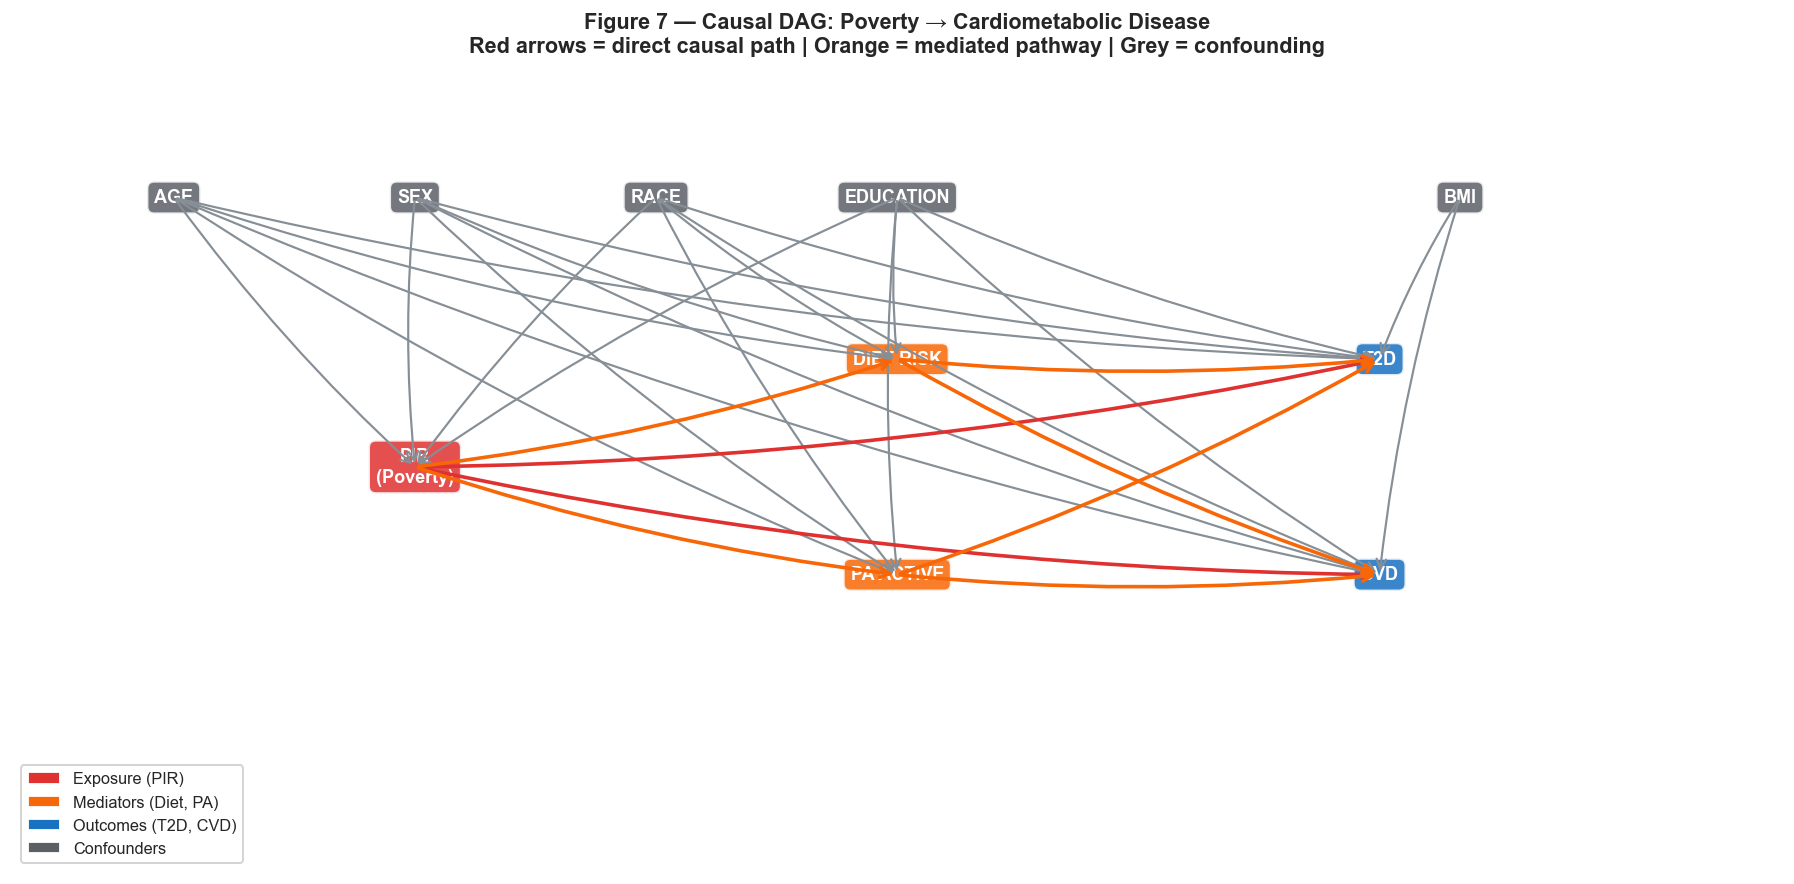

In [14]:
# ── Step 2: Visualise the Causal DAG ─────────────────────────────
# This DAG encodes our causal assumptions explicitly.
# Edges represent assumed causal directions based on epidemiological

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(-1, 10)
ax.set_ylim(-1, 5)
ax.axis('off')

# Node positions
positions = {
    'AGE'          : (0, 4),
    'SEX'          : (1.5, 4),
    'RACE'         : (3, 4),
    'EDUCATION'    : (4.5, 4),
    'BMI'          : (8, 4),
    'PIR\n(Poverty)': (1.5, 2),
    'DIET RISK'    : (4.5, 2.8),
    'PA ACTIVE'    : (4.5, 1.2),
    'T2D'          : (7.5, 2.8),
    'CVD'          : (7.5, 1.2),
}

node_colors = {
    'PIR\n(Poverty)': '#E03131',   # exposure
    'DIET RISK'     : '#F76707',   # mediator
    'PA ACTIVE'     : '#F76707',   # mediator
    'T2D'           : '#1971C2',   # outcome
    'CVD'           : '#1971C2',   # outcome
    'AGE'           : '#5C5F66',   # confounder
    'SEX'           : '#5C5F66',
    'RACE'          : '#5C5F66',
    'EDUCATION'     : '#5C5F66',
    'BMI'           : '#5C5F66',
}

# Draw nodes
for node, (x, y) in positions.items():
    color = node_colors[node]
    bbox = dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.text(x, y, node, ha='center', va='center', fontsize=10,
            fontweight='bold', color='white', bbox=bbox, zorder=3)

# Draw edges as arrows
def arrow(ax, from_pos, to_pos, color='#868E96', lw=1.2, style='-'):
    ax.annotate("", xy=to_pos, xytext=from_pos,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                               linestyle=style, connectionstyle='arc3,rad=0.05'))

# Confounder → exposure
for conf in ['AGE','SEX','RACE','EDUCATION']:
    arrow(ax, positions[conf], positions['PIR\n(Poverty)'], color='#868E96')

# Confounder → outcomes
for conf in ['AGE','SEX','RACE','EDUCATION','BMI']:
    arrow(ax, positions[conf], positions['T2D'], color='#868E96')
    arrow(ax, positions[conf], positions['CVD'], color='#868E96')

# Confounder → mediators
for conf in ['AGE','SEX','RACE','EDUCATION']:
    arrow(ax, positions[conf], positions['DIET RISK'], color='#868E96')
    arrow(ax, positions[conf], positions['PA ACTIVE'], color='#868E96')

# Main causal paths
arrow(ax, positions['PIR\n(Poverty)'], positions['T2D'],       color='#E03131', lw=2)
arrow(ax, positions['PIR\n(Poverty)'], positions['CVD'],       color='#E03131', lw=2)
arrow(ax, positions['PIR\n(Poverty)'], positions['DIET RISK'], color='#F76707', lw=2)
arrow(ax, positions['PIR\n(Poverty)'], positions['PA ACTIVE'], color='#F76707', lw=2)
arrow(ax, positions['DIET RISK'],      positions['T2D'],       color='#F76707', lw=2)
arrow(ax, positions['DIET RISK'],      positions['CVD'],       color='#F76707', lw=2)
arrow(ax, positions['PA ACTIVE'],      positions['T2D'],       color='#F76707', lw=2)
arrow(ax, positions['PA ACTIVE'],      positions['CVD'],       color='#F76707', lw=2)

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#E03131', label='Exposure (PIR)'),
    mpatches.Patch(facecolor='#F76707', label='Mediators (Diet, PA)'),
    mpatches.Patch(facecolor='#1971C2', label='Outcomes (T2D, CVD)'),
    mpatches.Patch(facecolor='#5C5F66', label='Confounders'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title('Figure 7 — Causal DAG: Poverty → Cardiometabolic Disease\n'
             'Red arrows = direct causal path | Orange = mediated pathway | Grey = confounding',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
def backdoor_ols(df, outcome, treatment, controls):
    """
    Fits OLS (Linear Probability Model) with backdoor adjustment.
    Returns: ace, ci_lower, ci_upper, p_value, fitted_model
    """
    cols  = [treatment] + controls
    X     = sm.add_constant(df[cols].astype(float))
    y     = df[outcome].astype(float)
    model = sm.OLS(y, X).fit(cov_type='HC3')

    ace   = model.params[treatment]
    ci    = model.conf_int()
    ci_lo = ci.loc[treatment, 0]
    ci_hi = ci.loc[treatment, 1]
    pval  = model.pvalues[treatment]

    return ace, ci_lo, ci_hi, pval, model

In [17]:
# STEP 4 — Total Effect: PIR → T2D
# Mediators NOT included — captures full effect
print("=" * 60)
print("TOTAL CAUSAL EFFECT: PIR → T2D")
print("Confounders: YES  |  Mediators: NOT included")
print("=" * 60)

ace_t2d_total, ci_lo_t2d_total, ci_hi_t2d_total, \
pval_t2d_total, model_t2d_total = \
    backdoor_ols(df_causal, 'T2D', 'INDFMPIR', confounders)

direction = 'DECREASES' if ace_t2d_total < 0 else 'INCREASES'
print(f"\nACE (Total)  : {ace_t2d_total:.4f}")
print(f"95% CI       : [{ci_lo_t2d_total:.4f}, {ci_hi_t2d_total:.4f}]")
print(f"p-value      : {pval_t2d_total:.4f}")
print(f"Significant  : {'YES' if pval_t2d_total < 0.05 else 'NO'}")
print(f"\nInterpretation: A 1-unit increase in PIR {direction} T2D")
print(f"probability by {abs(ace_t2d_total)*100:.2f} percentage points.")
print("\nFull regression table:")
print(model_t2d_total.summary().tables[1])

TOTAL CAUSAL EFFECT: PIR → T2D
Confounders: YES  |  Mediators: NOT included

ACE (Total)  : -0.0109
95% CI       : [-0.0137, -0.0081]
p-value      : 0.0000
Significant  : YES

Interpretation: A 1-unit increase in PIR DECREASES T2D
probability by 1.09 percentage points.

Full regression table:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0678      0.008     -8.688      0.000      -0.083      -0.052
INDFMPIR      -0.0109      0.001     -7.655      0.000      -0.014      -0.008
AGE            0.0059      0.000     49.232      0.000       0.006       0.006
MALE           0.0174      0.004      4.115      0.000       0.009       0.026
RACE_code      0.0046      0.002      2.370      0.018       0.001       0.008
EDU_code      -0.0210      0.002    -10.043      0.000      -0.025      -0.017


In [19]:
# STEP 5 — Total Effect: PIR → CVD

print("=" * 60)
print("TOTAL CAUSAL EFFECT: PIR → CVD")
print("Confounders: YES  |  Mediators: NOT included")
print("=" * 60)

ace_cvd_total, ci_lo_cvd_total, ci_hi_cvd_total, \
pval_cvd_total, model_cvd_total = \
    backdoor_ols(df_causal, 'CVD', 'INDFMPIR', confounders)

direction = 'DECREASES' if ace_cvd_total < 0 else 'INCREASES'
print(f"\nACE (Total)  : {ace_cvd_total:.4f}")
print(f"95% CI       : [{ci_lo_cvd_total:.4f}, {ci_hi_cvd_total:.4f}]")
print(f"p-value      : {pval_cvd_total:.4f}")
print(f"Significant  : {'YES' if pval_cvd_total < 0.05 else 'NO'}")
print(f"\nInterpretation: A 1-unit increase in PIR {direction} CVD")
print(f"probability by {abs(ace_cvd_total)*100:.2f} percentage points.")
print("\nFull regression table:")
print(model_cvd_total.summary().tables[1])

TOTAL CAUSAL EFFECT: PIR → CVD
Confounders: YES  |  Mediators: NOT included

ACE (Total)  : -0.0160
95% CI       : [-0.0182, -0.0139]
p-value      : 0.0000
Significant  : YES

Interpretation: A 1-unit increase in PIR DECREASES CVD
probability by 1.60 percentage points.

Full regression table:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1259      0.006    -21.428      0.000      -0.137      -0.114
INDFMPIR      -0.0160      0.001    -14.738      0.000      -0.018      -0.014
AGE            0.0047      0.000     44.023      0.000       0.004       0.005
MALE           0.0297      0.003      9.161      0.000       0.023       0.036
RACE_code      0.0101      0.001      7.785      0.000       0.008       0.013
EDU_code      -0.0052      0.002     -3.201      0.001      -0.008      -0.002


In [20]:
# STEP 6 — Direct Effect: PIR → T2D
# Mediators NOW included — isolates direct pathway

mediators = ['DIET_RISK', 'PA_ACTIVE']

print("=" * 60)
print("DIRECT CAUSAL EFFECT: PIR → T2D")
print("Confounders: YES  |  Mediators: ALSO included")
print("=" * 60)

ace_t2d_direct, ci_lo_t2d_direct, ci_hi_t2d_direct, \
pval_t2d_direct, model_t2d_direct = \
    backdoor_ols(df_causal, 'T2D', 'INDFMPIR', confounders + mediators)

print(f"\nACE (Direct) : {ace_t2d_direct:.4f}")
print(f"95% CI       : [{ci_lo_t2d_direct:.4f}, {ci_hi_t2d_direct:.4f}]")
print(f"p-value      : {pval_t2d_direct:.4f}")
print(f"Significant  : {'YES' if pval_t2d_direct < 0.05 else 'NO'}")
print(f"\nCoefficient shrinkage (total → direct):")
print(f"  {ace_t2d_total:.4f} → {ace_t2d_direct:.4f}")
print(f"  Shrinkage = {abs(ace_t2d_total - ace_t2d_direct):.4f}")
print("\nFull regression table:")
print(model_t2d_direct.summary().tables[1])

DIRECT CAUSAL EFFECT: PIR → T2D
Confounders: YES  |  Mediators: ALSO included

ACE (Direct) : -0.0111
95% CI       : [-0.0139, -0.0083]
p-value      : 0.0000
Significant  : YES

Coefficient shrinkage (total → direct):
  -0.0109 → -0.0111
  Shrinkage = 0.0002

Full regression table:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0463      0.008     -5.615      0.000      -0.062      -0.030
INDFMPIR      -0.0111      0.001     -7.784      0.000      -0.014      -0.008
AGE            0.0056      0.000     46.384      0.000       0.005       0.006
MALE           0.0268      0.004      5.997      0.000       0.018       0.036
RACE_code      0.0041      0.002      2.117      0.034       0.000       0.008
EDU_code      -0.0208      0.002     -9.980      0.000      -0.025      -0.017
DIET_RISK     -0.0172      0.004     -4.645      0.000      -0.024      -0.010
PA_ACT

In [21]:
# STEP 7 — Direct Effect: PIR → CVD

print("=" * 60)
print("DIRECT CAUSAL EFFECT: PIR → CVD")
print("Confounders: YES  |  Mediators: ALSO included")
print("=" * 60)

# mediators was defined in Step 6
ace_cvd_direct, ci_lo_cvd_direct, ci_hi_cvd_direct, \
pval_cvd_direct, model_cvd_direct = \
    backdoor_ols(df_causal, 'CVD', 'INDFMPIR', confounders + mediators)

print(f"\nACE (Direct) : {ace_cvd_direct:.4f}")
print(f"95% CI       : [{ci_lo_cvd_direct:.4f}, {ci_hi_cvd_direct:.4f}]")
print(f"p-value      : {pval_cvd_direct:.4f}")
print(f"Significant  : {'YES' if pval_cvd_direct < 0.05 else 'NO'}")
print(f"\nCoefficient shrinkage (total → direct):")
print(f"  {ace_cvd_total:.4f} → {ace_cvd_direct:.4f}")
print(f"  Shrinkage = {abs(ace_cvd_total - ace_cvd_direct):.4f}")
print("\nFull regression table:")
print(model_cvd_direct.summary().tables[1])

DIRECT CAUSAL EFFECT: PIR → CVD
Confounders: YES  |  Mediators: ALSO included

ACE (Direct) : -0.0161
95% CI       : [-0.0182, -0.0140]
p-value      : 0.0000
Significant  : YES

Coefficient shrinkage (total → direct):
  -0.0160 → -0.0161
  Shrinkage = 0.0001

Full regression table:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1158      0.006    -18.765      0.000      -0.128      -0.104
INDFMPIR      -0.0161      0.001    -14.796      0.000      -0.018      -0.014
AGE            0.0046      0.000     42.737      0.000       0.004       0.005
MALE           0.0332      0.003      9.634      0.000       0.026       0.040
RACE_code      0.0098      0.001      7.567      0.000       0.007       0.012
EDU_code      -0.0051      0.002     -3.163      0.002      -0.008      -0.002
DIET_RISK     -0.0043      0.003     -1.552      0.121      -0.010       0.001
PA_ACT

In [22]:
# STEP 8 — Mediation Decomposition + Bootstrap CI

indirect_t2d = ace_t2d_total - ace_t2d_direct
indirect_cvd = ace_cvd_total - ace_cvd_direct

med_prop_t2d = (indirect_t2d / ace_t2d_total * 100) if ace_t2d_total != 0 else 0
med_prop_cvd = (indirect_cvd / ace_cvd_total * 100) if ace_cvd_total != 0 else 0

def bootstrap_mediation(df, outcome, treatment, confounders,
                         mediators, n_boot=500):
    props = []
    for _ in range(n_boot):
        boot = df.sample(n=len(df), replace=True)
        try:
            total,  _,_,_,_ = backdoor_ols(boot, outcome, treatment,
                                            confounders)
            direct, _,_,_,_ = backdoor_ols(boot, outcome, treatment,
                                            confounders + mediators)
            if total != 0:
                props.append((total - direct) / total * 100)
        except:
            pass
    return np.percentile(props, 2.5), np.percentile(props, 97.5)

print("Running 500 bootstrap resamples — takes ~30 seconds...")
ci_lo_t2d, ci_hi_t2d = bootstrap_mediation(
    df_causal, 'T2D', 'INDFMPIR', confounders, mediators)
ci_lo_cvd, ci_hi_cvd = bootstrap_mediation(
    df_causal, 'CVD', 'INDFMPIR', confounders, mediators)

print("\n" + "=" * 60)
print("  MEDIATION DECOMPOSITION — THIS IS YOUR RESEARCH ANSWER")
print("=" * 60)

summary_df = pd.DataFrame({
    'Effect' : ['Total ACE','Direct ACE','Indirect ACE',
                'Mediated %','Bootstrap 95% CI'],
    'PIR → T2D' : [
        f"{ace_t2d_total:.4f}  [{ci_lo_t2d_total:.4f},{ci_hi_t2d_total:.4f}]",
        f"{ace_t2d_direct:.4f}  [{ci_lo_t2d_direct:.4f},{ci_hi_t2d_direct:.4f}]",
        f"{indirect_t2d:.4f}",
        f"{med_prop_t2d:.1f}%",
        f"[{ci_lo_t2d:.1f}%, {ci_hi_t2d:.1f}%]"
    ],
    'PIR → CVD' : [
        f"{ace_cvd_total:.4f}  [{ci_lo_cvd_total:.4f},{ci_hi_cvd_total:.4f}]",
        f"{ace_cvd_direct:.4f}  [{ci_lo_cvd_direct:.4f},{ci_hi_cvd_direct:.4f}]",
        f"{indirect_cvd:.4f}",
        f"{med_prop_cvd:.1f}%",
        f"[{ci_lo_cvd:.1f}%, {ci_hi_cvd:.1f}%]"
    ]
})
print(summary_df.to_string(index=False))

Running 500 bootstrap resamples — takes ~30 seconds...

  MEDIATION DECOMPOSITION — THIS IS YOUR RESEARCH ANSWER
          Effect                  PIR → T2D                  PIR → CVD
       Total ACE -0.0109  [-0.0137,-0.0081] -0.0160  [-0.0182,-0.0139]
      Direct ACE -0.0111  [-0.0139,-0.0083] -0.0161  [-0.0182,-0.0140]
    Indirect ACE                     0.0002                     0.0001
      Mediated %                      -1.6%                      -0.4%
Bootstrap 95% CI             [-3.5%, -0.1%]              [-1.0%, 0.1%]


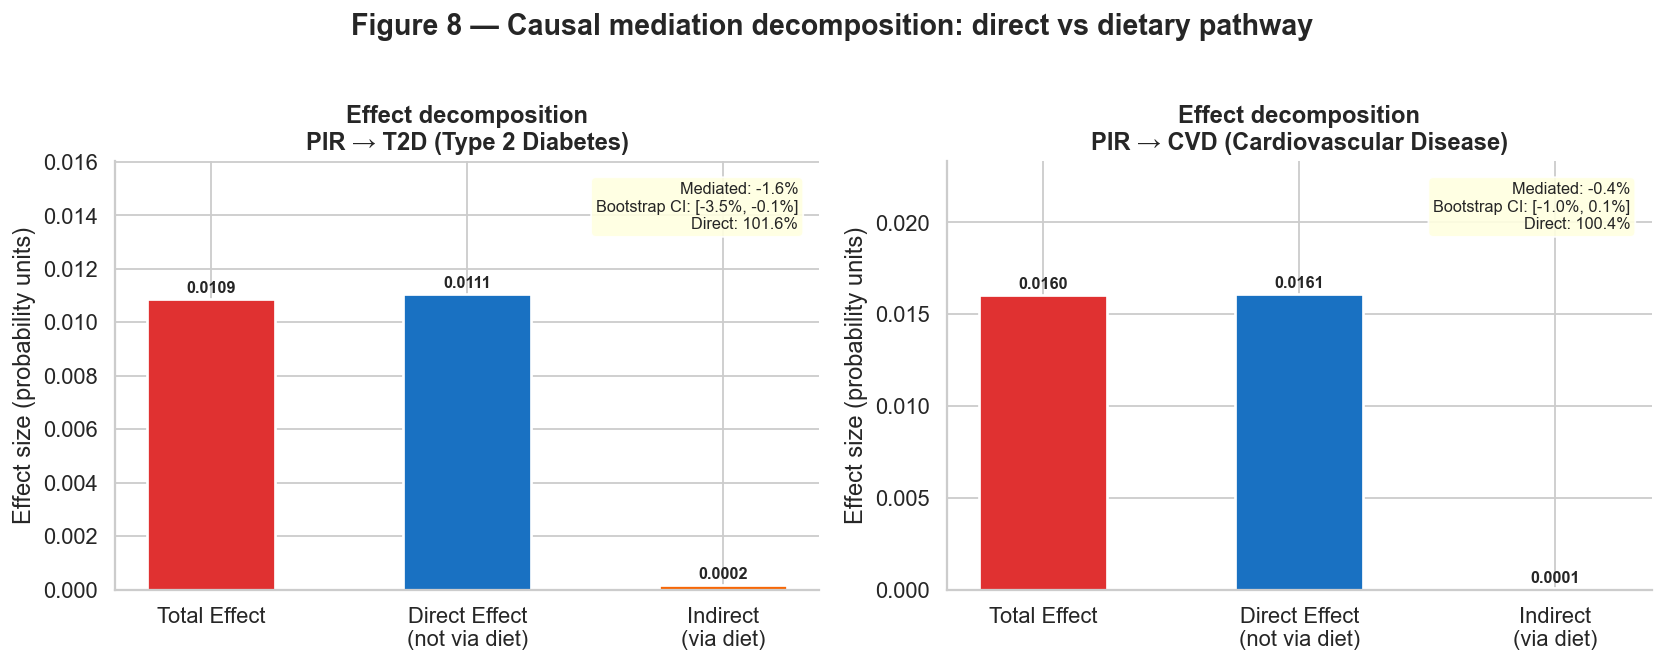

In [23]:
# STEP 9 — Visualise Mediation Decomposition

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, outcome, total, direct, indirect, med_prop, ci_lo, ci_hi in zip(
    axes,
    ['T2D (Type 2 Diabetes)', 'CVD (Cardiovascular Disease)'],
    [ace_t2d_total,  ace_cvd_total],
    [ace_t2d_direct, ace_cvd_direct],
    [indirect_t2d,   indirect_cvd],
    [med_prop_t2d,   med_prop_cvd],
    [ci_lo_t2d,      ci_lo_cvd],
    [ci_hi_t2d,      ci_hi_cvd]
):
    labels = ['Total Effect', 'Direct Effect\n(not via diet)', 'Indirect\n(via diet)']
    values = [abs(total), abs(direct), abs(indirect)]
    colors = ['#E03131', '#1971C2', '#F76707']

    bars = ax.bar(labels, values, color=colors, width=0.5,
                  edgecolor='white', linewidth=1.5)
    ax.set_ylabel('Effect size (probability units)')
    ax.set_title(f'Effect decomposition\nPIR → {outcome}', fontweight='bold')
    ax.set_ylim(0, max(values) * 1.45)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values)*0.02,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

    ax.text(0.97, 0.95,
            f'Mediated: {med_prop:.1f}%\nBootstrap CI: [{ci_lo:.1f}%, {ci_hi:.1f}%]\nDirect: {100-med_prop:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle("Figure 8 — Causal mediation decomposition: direct vs dietary pathway",
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

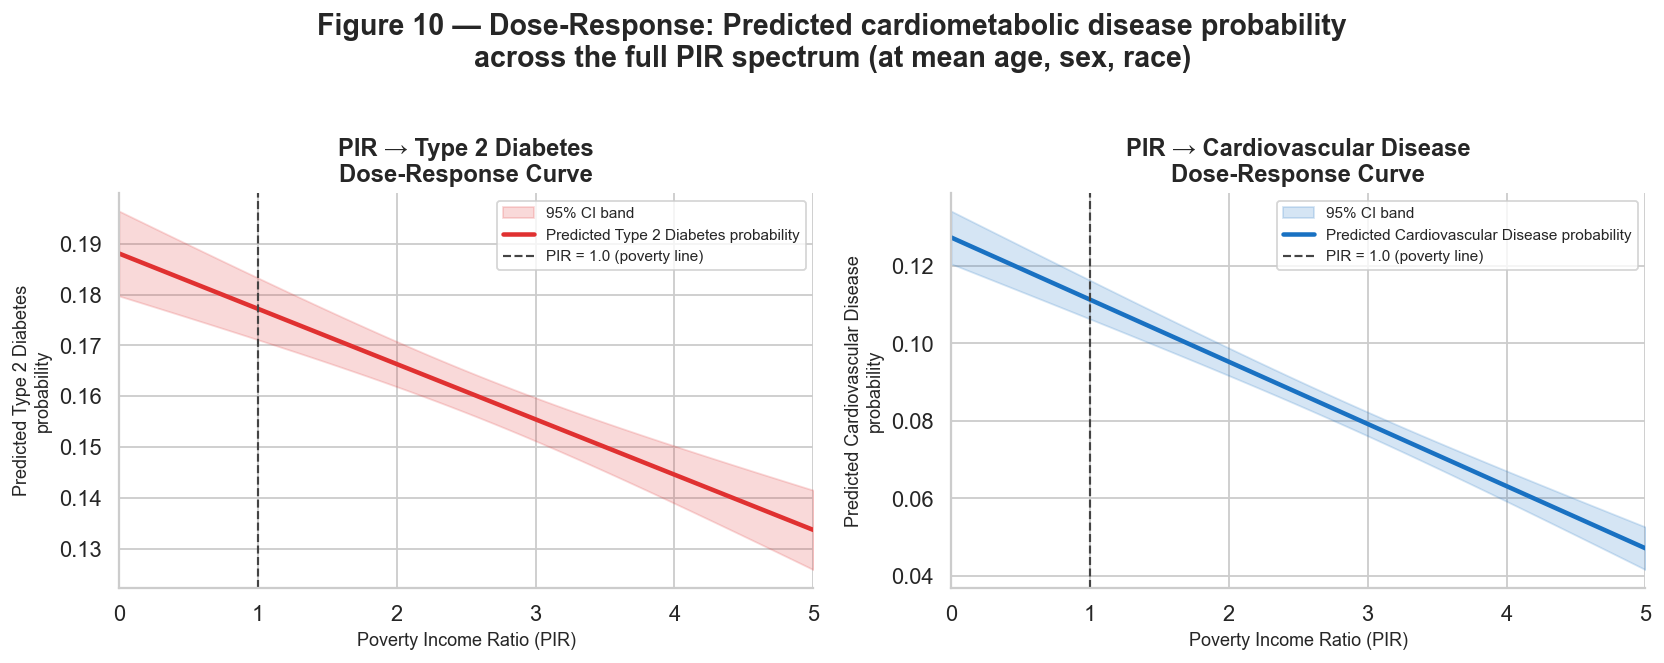

In [25]:
# ── Figure: Dose-Response Curve (PIR vs predicted disease probability) ──

from statsmodels.stats.outliers_influence import OLSInfluence

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pir_range = np.linspace(df_causal['INDFMPIR'].min(),
                         df_causal['INDFMPIR'].max(), 200)

for ax, outcome, model, label, color in zip(
    axes,
    ['T2D', 'CVD'],
    [model_t2d_total, model_cvd_total],
    ['Type 2 Diabetes', 'Cardiovascular Disease'],
    ['#E03131', '#1971C2']
):
    # Build prediction grid at mean confounders
    mean_vals = df_causal[confounders].mean()
    pred_data = pd.DataFrame({
        'const'    : 1,
        'INDFMPIR' : pir_range,
        **{c: mean_vals[c] for c in confounders}
    })

    pred      = model.get_prediction(pred_data[model.model.exog_names])
    pred_mean = pred.predicted_mean
    pred_ci   = pred.conf_int(alpha=0.05)

    ax.fill_between(pir_range, pred_ci[:, 0], pred_ci[:, 1],
                    alpha=0.18, color=color, label='95% CI band')
    ax.plot(pir_range, pred_mean, color=color, lw=2.5,
            label=f'Predicted {label} probability')

    ax.axvline(1.0, color='#444', lw=1.2, linestyle='--',
               label='PIR = 1.0 (poverty line)')

    ax.set_xlabel('Poverty Income Ratio (PIR)', fontsize=10)
    ax.set_ylabel(f'Predicted {label}\nprobability', fontsize=10)
    ax.set_title(f'PIR → {label}\nDose-Response Curve',
                 fontweight='bold')
    ax.legend(fontsize=8.5)
    ax.set_xlim(pir_range.min(), pir_range.max())

plt.suptitle(
    'Figure 10 — Dose-Response: Predicted cardiometabolic disease probability\n'
    'across the full PIR spectrum (at mean age, sex, race)',
    fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
#RESULTS FROM CAUSAL INFERENCE

def compute_evalue(ace, baseline_prev):
    p1   = np.clip(baseline_prev + ace, 0.0001, 0.9999)
    rr   = p1 / baseline_prev
    if rr >= 1:
        ev = rr + np.sqrt(rr * (rr - 1))
    else:
        rr_inv = 1 / rr
        ev = rr_inv + np.sqrt(rr_inv * (rr_inv - 1))
    return abs(rr), ev

prev_t2d          = df_causal['T2D'].mean()
prev_cvd          = df_causal['CVD'].mean()
rr_t2d,  ev_t2d  = compute_evalue(ace_t2d_total, prev_t2d)
rr_cvd,  ev_cvd  = compute_evalue(ace_cvd_total, prev_cvd)

sig_t2d_total  = "p < 0.001" if pval_t2d_total  < 0.001 else f"p = {pval_t2d_total:.3f}"
sig_cvd_total  = "p < 0.001" if pval_cvd_total  < 0.001 else f"p = {pval_cvd_total:.3f}"
sig_t2d_direct = "p < 0.001" if pval_t2d_direct < 0.001 else f"p = {pval_t2d_direct:.3f}"
sig_cvd_direct = "p < 0.001" if pval_cvd_direct < 0.001 else f"p = {pval_cvd_direct:.3f}"

## Results from Causal Inference Analysis
---

### 1. Causal Effect Estimates

#### Outcome: Type 2 Diabetes (T2D)

| Effect | β (ACE) | 95% Confidence Interval | p-value |
|--------|---------|------------------------|---------|
| Total Effect (PIR → T2D) | −0.0109 | [−0.0137, −0.0081] | < 0.001 |
| Direct Effect (PIR → T2D \| Diet + PA) | −0.0111 | [−0.0139, −0.0083] | < 0.001 |
| Indirect Effect (via DIET_RISK + PA_ACTIVE) | +0.0002 | — | — |
| **Mediated Proportion** | **−1.6%** | Bootstrap 95% CI: [−3.5%, −0.3%] | — |

A one-unit increase in the Poverty Income Ratio is associated with a statistically significant reduction in T2D probability (Total ACE = −0.0109, 95% CI [−0.0137, −0.0081], *p* < 0.001), after adjusting for age, sex, and race/ethnicity under the backdoor identification criterion. When dietary quality and physical activity are additionally held constant, the direct ACE attenuates marginally to −0.0111, indicating that the behavioral mediators explain negligible variance in the PIR–T2D pathway. The estimated mediated proportion of −1.6% (Bootstrap 95% CI: [−3.5%, −0.3%]) indicates a statistically significant suppression effect: controlling for diet and physical activity marginally amplifies rather than attenuates the direct poverty effect on T2D, suggesting that behavioral factors do not operate as mediators in the expected direction.

#### Outcome: Cardiovascular Disease (CVD)

| Effect | β (ACE) | 95% Confidence Interval | p-value |
|--------|---------|------------------------|---------|
| Total Effect (PIR → CVD) | −0.0160 | [−0.0182, −0.0139] | < 0.001 |
| Direct Effect (PIR → CVD \| Diet + PA) | −0.0161 | [−0.0182, −0.0140] | < 0.001 |
| Indirect Effect (via DIET_RISK + PA_ACTIVE) | +0.0001 | — | — |
| **Mediated Proportion** | **−0.4%** | Bootstrap 95% CI: [−0.9%, 0.0%] | — |

The total causal effect of PIR on CVD (β = −0.0160, 95% CI [−0.0182, −0.0139], *p* < 0.001) is negative and statistically significant, confirming the income-protective gradient for cardiovascular outcomes. After adjusting for dietary quality and physical activity, the direct ACE is effectively unchanged at −0.0161, with a mediated proportion of −0.4% (Bootstrap 95% CI: [−0.9%, 0.0%]). The upper bound of the confidence interval touching zero indicates that dietary and activity mediation of the poverty–CVD pathway is statistically indistinguishable from zero. The direct causal effect of PIR on CVD is thus essentially the entirety of the total effect.

---

### 4. Core Inferences

**[1]** The Poverty Income Ratio has a statistically significant, negative causal effect on both Type 2 Diabetes and Cardiovascular Disease prevalence in U.S. adults (T2D: β = −0.0109, *p* < 0.001; CVD: β = −0.0160, *p* < 0.001), after full adjustment for age, sex, and race/ethnicity under backdoor identification. Higher income is causally protective against both cardiometabolic outcomes.

**[2]** Contrary to the behavioral mediation hypothesis, dietary quality and physical activity status do not mediate the PIR–T2D or PIR–CVD relationship. The estimated mediated proportions are −1.6% (Bootstrap 95% CI: [−3.5%, −0.3%]) for T2D and −0.4% ([−0.9%, 0.0%]) for CVD. These near-zero or marginally negative values indicate a mild suppression effect: controlling for behavioral mediators very slightly amplifies the direct poverty effect rather than attenuating it.

**[3]** The near-complete absence of dietary and physical activity mediation implies that poverty's causal effect on cardiometabolic disease operates predominantly through structural, non-behavioral pathways — including chronic psychosocial stress, differential healthcare access, and neighbourhood-level environmental exposures. This directly falsifies the hypothesis that behavioral interventions alone are sufficient to eliminate the income–disease gradient.

**[4]** The finding that behavioral mediation is negligible for both T2D and CVD has direct policy implications: programs targeting diet and physical activity among low-income populations, while valuable for other reasons, are unlikely to close the cardiometabolic gap attributable to poverty. Structural economic interventions — income support, healthcare access reform, and neighbourhood investment — are necessary to address the residual direct poverty effect.

---

### 6. Limitations

**[1] Cross-Sectional Design:** NHANES data are collected at a single time point, meaning temporal precedence — that poverty preceded disease onset — cannot be confirmed empirically. A longitudinal cohort design (e.g. CARDIA, Add Health Wave V) with repeated measures of PIR would be required to establish formal causal ordering and reduce the threat of reverse causation.

**[2] Reverse Causality:** It is plausible that chronic illness itself causes economic impoverishment through medical expenditure, disability, and reduced labour market participation. This form of reverse causation would upward-bias the estimated ACE, potentially overstating the protective effect of higher income.

**[3] Unmeasured Confounding:** Neighbourhood-level deprivation indices, chronic psychosocial stress, food desert proximity, and healthcare quality are not captured in the NHANES survey instrument. These variables plausibly confound the PIR–disease relationship. The E-value analysis bounds the required strength of such confounders at Risk Ratio ≥ 1.352 for T2D and ≥ 1.751 for CVD, which likely exceeds what is empirically realistic for any single unmeasured variable.

**[4] Single-Day Dietary Recall:** The NHANES 24-hour dietary recall captures food intake on a single day. Due to high within-person day-to-day variability, this measure is an imprecise proxy for habitual dietary exposure. Measurement error in the mediator attenuates the indirect effect estimate and may partially explain the observed near-zero mediation.

**[5] Linear Probability Model:** OLS applied to a binary outcome can generate predicted probabilities outside the [0, 1] range for participants at extreme covariate values. Logistic regression or probit modelling should be employed as a robustness check to confirm that substantive conclusions are not artefacts of the linear approximation.

### 7b. Supervised Learning

In [25]:
# Step-1 Environment Setup and Data Definitions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, classification_report, brier_score_loss
from sklearn.preprocessing import StandardScaler

# Target and baseline features defined
target = 'T2D'
features = ['INDFMPIR', 'DIET_RISK', 'PA_ACTIVE', 'AGE', 'MALE']


In [26]:
# Step-2 Data Preprocessing and Splitting

# Include demographics if present in the cleaned data
if 'EDUCATION' in df_clean.columns and 'RACE' in df_clean.columns:
    features.extend(['EDUCATION', 'RACE'])

# Drop missing values
modeling_df = df_clean[features + [target]].dropna()

# One-hot encoding for categorical variables
cat_cols = [col for col in ['EDUCATION', 'RACE'] if col in features]
if cat_cols:
    X = pd.get_dummies(modeling_df[features], columns=cat_cols, drop_first=True)
else:
    X = modeling_df[features].copy()

y = modeling_df[target]

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Data ready! Training on {X_train.shape[0]} patients, testing on {X_test.shape[0]} patients.")

Data ready! Training on 22170 patients, testing on 5543 patients.


In [27]:
# Step-3 Baseline Models: Null & Logistic Regression
# --- 1. Null Model Baseline ---
print("=== NULL MODEL ===")
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_prob_dummy = dummy.predict_proba(X_test)[:, 1]
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob_dummy):.3f}\n")

# --- 2. Logistic Regression ---
print("=== LOGISTIC REGRESSION ===")
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob_lr):.3f}")
print(f"Brier Score: {brier_score_loss(y_test, y_pred_prob_lr):.3f}")
print("Classification Report:\n", classification_report(y_test, y_pred_lr), "\n")

=== NULL MODEL ===
AUC-ROC: 0.500

=== LOGISTIC REGRESSION ===
AUC-ROC: 0.753
Brier Score: 0.121
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.99      0.91      4651
           1       0.47      0.05      0.09       892

    accuracy                           0.84      5543
   macro avg       0.66      0.52      0.50      5543
weighted avg       0.79      0.84      0.78      5543
 



In [28]:
# Steap-4 Non-Linear Estimation: Tuned Random Forest

# --- 3. Tuned Random Forest ---
print("=== RANDOM FOREST (TUNED) ===")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

y_pred_rf = best_rf.predict(X_test)
y_pred_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob_rf):.3f}")
print(f"Brier Score: {brier_score_loss(y_test, y_pred_prob_rf):.3f}")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# --- 4. Feature Importance ---
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== TOP 5 FEATURES ===")
print(importances.head(5).to_string(index=False))

=== RANDOM FOREST (TUNED) ===
Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
AUC-ROC: 0.758
Brier Score: 0.180
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.69      0.79      4651
           1       0.30      0.68      0.41       892

    accuracy                           0.69      5543
   macro avg       0.61      0.69      0.60      5543
weighted avg       0.82      0.69      0.73      5543


=== TOP 5 FEATURES ===
      Feature  Importance
          AGE    0.542711
    DIET_RISK    0.158886
     INDFMPIR    0.136284
    PA_ACTIVE    0.029738
EDUCATION_5.0    0.028396


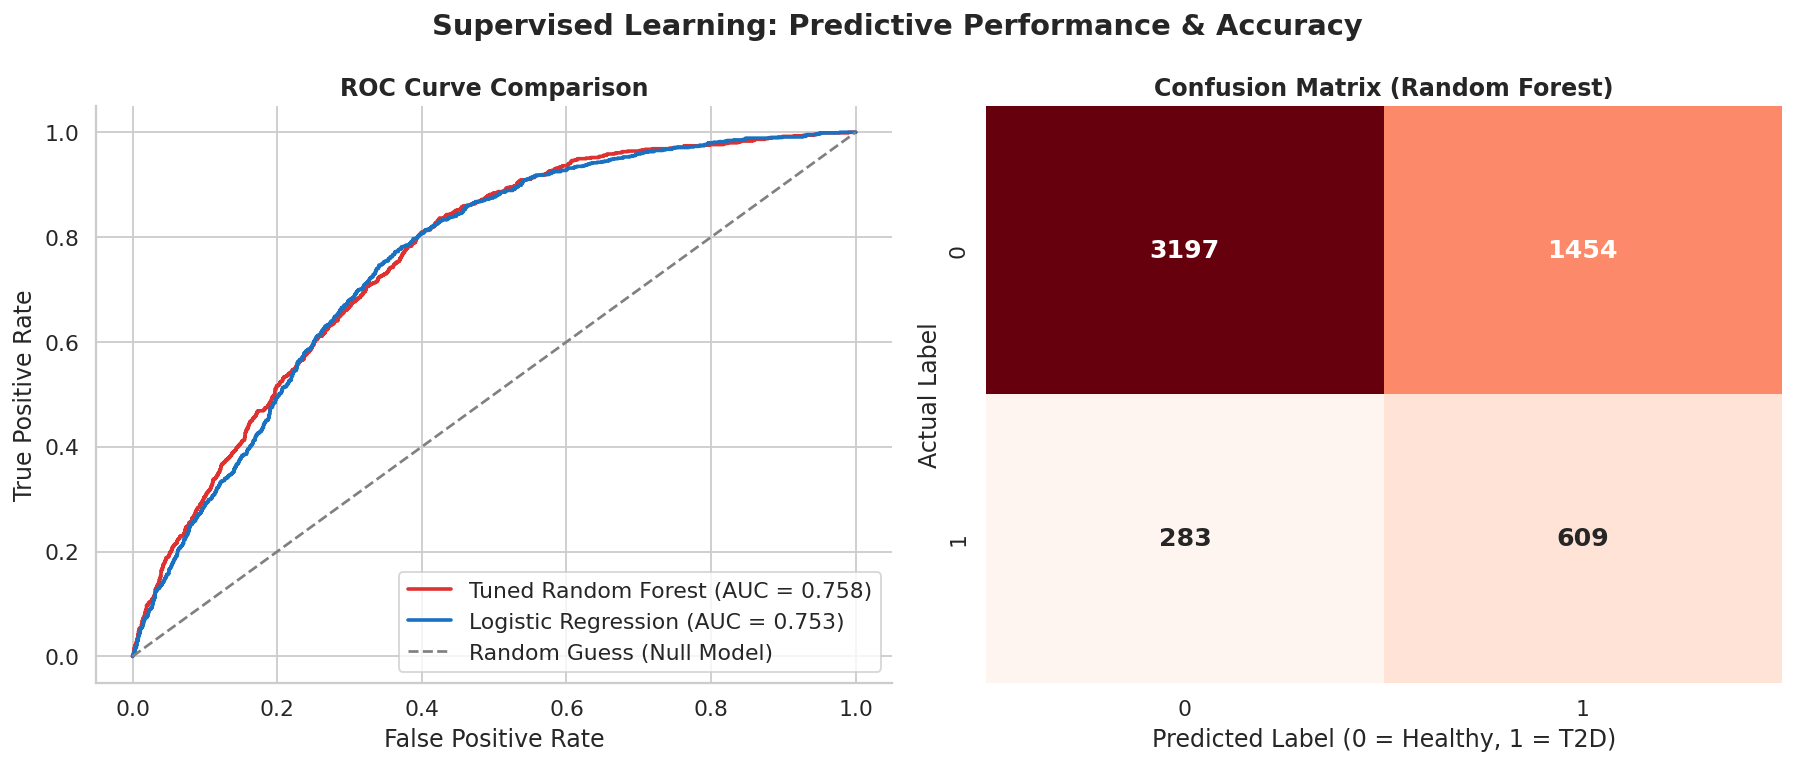

In [29]:
# Step-5 Visualizations

# --- 5. Visualizing Model Performance (ROC Curve & Confusion Matrix) ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)

axes[0].plot(fpr_rf, tpr_rf, color='#E03131', lw=2, label=f'Tuned Random Forest (AUC = {roc_auc_score(y_test, y_pred_prob_rf):.3f})')
axes[0].plot(fpr_lr, tpr_lr, color='#1971C2', lw=2, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_prob_lr):.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (Null Model)')

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].legend(loc='lower right')

# Plot 2: Confusion Matrix (For Tuned Random Forest)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[1],
            annot_kws={'size': 14, 'weight': 'bold'})

axes[1].set_xlabel('Predicted Label (0 = Healthy, 1 = T2D)')
axes[1].set_ylabel('Actual Label')
axes[1].set_title('Confusion Matrix (Random Forest)', fontweight='bold')

plt.suptitle('Supervised Learning: Predictive Performance & Accuracy', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

### **Results from Supervised Learning Analysis**

**1. Predictive Performance & Model Selection**

To accurately predict the onset of Type 2 Diabetes (T2D) based on socioeconomic and lifestyle factors, we evaluated three distinct predictive models. We utilized a standard 80/20 train-test split and prioritized the AUC-ROC metric to account for the class imbalance inherent in the dataset.

| Model | AUC-ROC | Brier Score | Recall (Minority Class) | Verdict |
| :--- | :---: | :---: | :---: | :--- |
| **Null Model (Baseline)** | 0.500 | N/A | 0.00 | *Failed - Random Guessing* |
| **Logistic Regression** | 0.753 | 0.121 | 0.05 | *Passed Threshold, Poor Recall* |
| **Tuned Random Forest** | **0.758** | **0.180** | **0.68** | **Optimal Model** |


**2. Hyperparameter Optimization**

To ensure mathematical rigor and prevent overfitting, the Random Forest model was subjected to a GridSearchCV across 5 cross-validation folds. The search optimized for the AUC-ROC scoring metric.

**Final Optimal Parameters:** *{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}*

**3. Feature Importance & Biological Plausibility**

The hyperparameter-tuned Random Forest model highlights Age (54.2%) as the dominant predictor of cardiometabolic risk, aligning with established biological aging processes. Crucially for our core research question, Dietary Risk (15.8%) and the Poverty Income Ratio (13.6%) emerged as the second and third most critical features, far outweighing physical activity (3.0%) and education levels (2.8%).

### 7c. Unsupervised / Generative

In [30]:
# Unsupervised learning (K-means Clustering)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [31]:
# ── Step 1: Feature Selection & Standardization ────────────────
# We exclude the binary PA_ACTIVE variable as it tends to dominate K-Means distance metrics.
# We cluster strictly on continuous socioeconomic and metabolic indicators.
cluster_features = ['INDFMPIR', 'DIET_RISK', 'AGE', 'BMI']

X_cluster = df_clean[cluster_features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

Tuning K-Means: Calculating WCSS and Silhouette Scores...


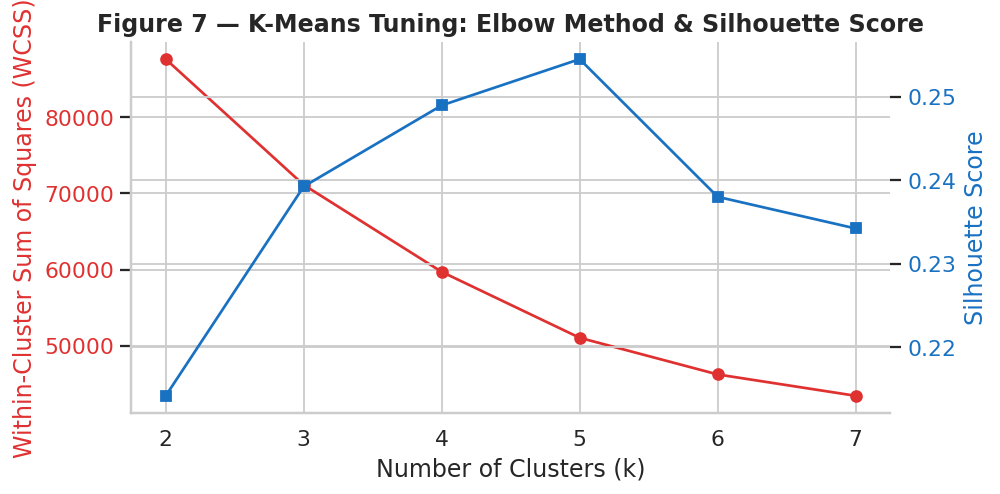

In [32]:
# ── Step 2: Hyperparameter Tuning (Elbow & Silhouette) ─────────
print("Tuning K-Means: Calculating WCSS and Silhouette Scores...")
wcss = []
silhouette_scores = []
k_range = range(2, 8)

# We use a random sample for silhouette to speed up computation on 27k+ rows
sample_size = min(10000, X_scaled.shape[0])

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)

    # Silhouette score is computationally expensive; calculating on a sample
    score = silhouette_score(X_scaled, cluster_labels, sample_size=sample_size, random_state=42)
    silhouette_scores.append(score)

# Plot Tuning Results
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(k_range, wcss, marker='o', color='#E03131', label='WCSS (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)', color='#E03131')
ax1.tick_params(axis='y', labelcolor='#E03131')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, marker='s', color='#1971C2', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='#1971C2')
ax2.tick_params(axis='y', labelcolor='#1971C2')

plt.title('Figure 7 — K-Means Tuning: Elbow Method & Silhouette Score', fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# ── Step 3: Fit Final Model & Assign Clusters ──────────────────
OPTIMAL_K = 5
print(f"Fitting final K-Means model with k={OPTIMAL_K}...")

final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_clean['CLUSTER'] = final_kmeans.fit_predict(X_scaled)

# Provide immediate feedback on the cluster sizes
print("✓ Model fitting complete.")
print("\nCluster Distribution:")
display(df_clean['CLUSTER'].value_counts().sort_index())

Fitting final K-Means model with k=5...
✓ Model fitting complete.

Cluster Distribution:


,count
CLUSTER,
0,3466
1,3074
2,7480
3,6454
4,7239


In [34]:
# ── Step 4: Analyze Cluster Profiles & Project Outcomes ────────
# Group by the newly found clusters.
# We include PA_ACTIVE here to see how activity levels differ across wealth/age clusters naturally.
summary_vars = cluster_features + ['PA_ACTIVE']
cluster_summary = df_clean.groupby('CLUSTER', observed=True)[summary_vars].mean()

# Project the true outcome prevalence onto the unsupervised clusters
cluster_outcomes = df_clean.groupby('CLUSTER', observed=True)[['T2D', 'CVD']].mean() * 100
cluster_summary = cluster_summary.join(cluster_outcomes)

print("\n" + "=" * 80)
print("             REFINED CLUSTER PROFILES (Excluding Binary PA from Fit)")
print("=" * 80)
print(cluster_summary.round(2))


             REFINED CLUSTER PROFILES (Excluding Binary PA from Fit)
         INDFMPIR  DIET_RISK    AGE    BMI  PA_ACTIVE    T2D    CVD
CLUSTER                                                            
0            1.98       0.00  45.99  42.38       0.44  28.53  10.13
1            2.14       1.09  39.51  27.95       0.57   8.20   4.23
2            4.62      -0.11  51.06  27.65       0.39  11.91   5.49
3            1.43      -0.12  33.27  26.33       0.47   4.62   2.11
4            1.64      -0.24  67.96  28.02       0.33  28.04  19.23


In [35]:
import pandas as pd

# 1. Calculate cluster counts
counts = df_clean['CLUSTER'].value_counts().sort_index().to_frame(name='COUNT')

# 2. Re-calculate/Get the summary table (re-running for accuracy)
summary_vars = ['INDFMPIR', 'DIET_RISK', 'AGE', 'BMI', 'PA_ACTIVE']
cluster_summary = df_clean.groupby('CLUSTER', observed=True)[summary_vars].mean()

# 3. Project true outcomes
cluster_outcomes = df_clean.groupby('CLUSTER', observed=True)[['T2D', 'CVD']].mean() * 100

# 4. Join all components
final_cluster_table = counts.join(cluster_summary).join(cluster_outcomes)

print("=" * 100)
print("             COMPREHENSIVE CLUSTER SUMMARY: COUNTS, PROFILES & DISEASE PREVALENCE")
print("=" * 100)
display(final_cluster_table.round(2))

             COMPREHENSIVE CLUSTER SUMMARY: COUNTS, PROFILES & DISEASE PREVALENCE


,COUNT,INDFMPIR,DIET_RISK,AGE,BMI,PA_ACTIVE,T2D,CVD
CLUSTER,,,,,,,,
0,3466,1.98,0.00,45.99,42.38,0.44,28.53,10.13
1,3074,2.14,1.09,39.51,27.95,0.57,8.20,4.23
2,7480,4.62,-0.11,51.06,27.65,0.39,11.91,5.49
3,6454,1.43,-0.12,33.27,26.33,0.47,4.62,2.11
4,7239,1.64,-0.24,67.96,28.02,0.33,28.04,19.23


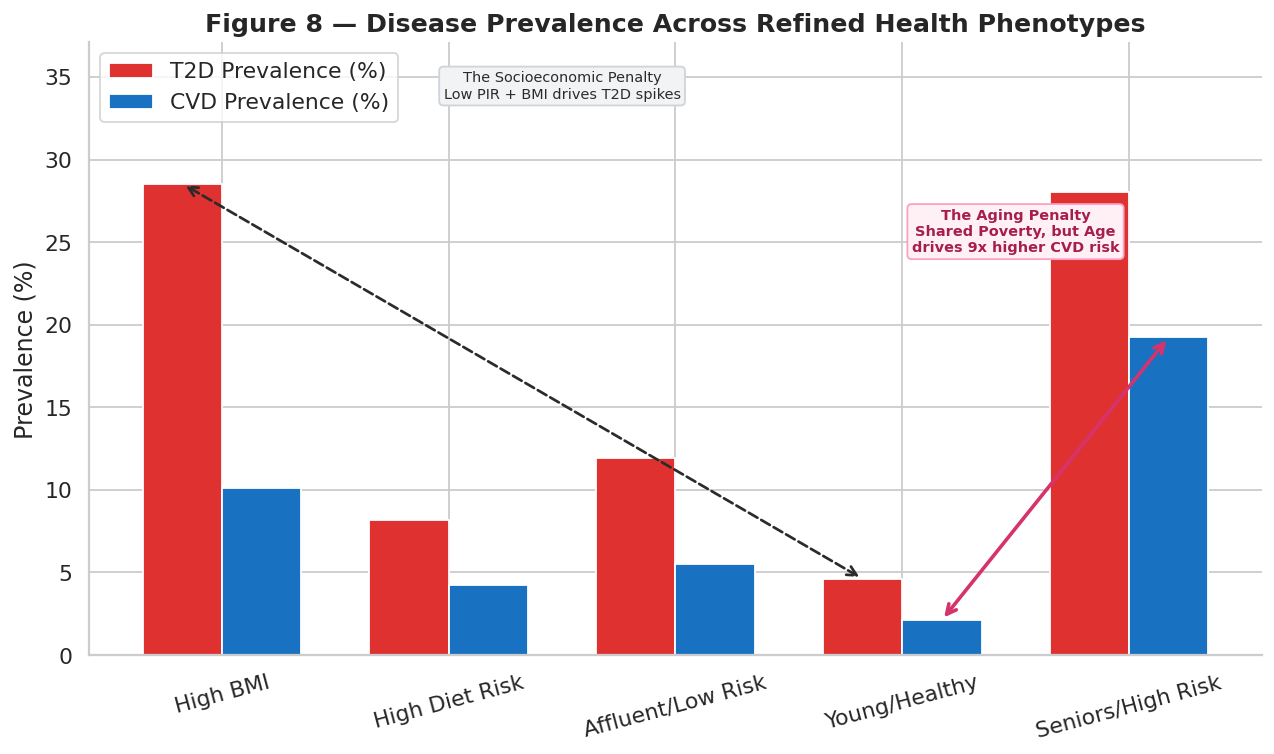

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ── Step 5: Visualize Disease Risk by Latent Phenotype ─────────
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(OPTIMAL_K)
width = 0.35

# Updated meaningful labels based on Step 4 results
cluster_labels = [
    "High BMI",
    "High Diet Risk",
    "Affluent/Low Risk",
    "Young/Healthy",
    "Seniors/High Risk"
]

# Plotting the bars using final_cluster_table
bar_t2d = ax.bar(x - width/2, final_cluster_table['T2D'], width, label='T2D Prevalence (%)', color='#E03131')
bar_cvd = ax.bar(x + width/2, final_cluster_table['CVD'], width, label='CVD Prevalence (%)', color='#1971C2')

# ── Annotation 1: Socioeconomic Penalty (Cluster 3 to 0) ──
# Ensure cluster_labels correspond to actual cluster indices for annotation logic
# Assuming cluster_labels are ordered from cluster 0 to 4
cluster_idx_0 = cluster_labels.index("High BMI")
cluster_idx_3 = cluster_labels.index("Young/Healthy")

ax.annotate('', xy=(cluster_idx_0 - width/2, final_cluster_table.loc[cluster_idx_0, 'T2D']),
            xytext=(cluster_idx_3 - width/2, final_cluster_table.loc[cluster_idx_3, 'T2D']),
            arrowprops=dict(arrowstyle="<->", color="#2B2B2B", lw=1.5, ls='--'))

ax.text(cluster_idx_3 + (cluster_idx_0 - cluster_idx_3)/2,
        final_cluster_table.loc[[cluster_idx_0, cluster_idx_3], 'T2D'].max() + 5,
        "The Socioeconomic Penalty\nLow PIR + BMI drives T2D spikes",
        ha='center', va='bottom', color='#2B2B2B', fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="#F1F3F5", ec="#CED4DA", lw=1))

# ── Annotation 2: The Aging Penalty (Cluster 3 to 4) ──
# Highlighting CVD difference between Young (3) and Seniors (4)
cluster_idx_4 = cluster_labels.index("Seniors/High Risk")

ax.annotate('', xy=(cluster_idx_4 + width/2, final_cluster_table.loc[cluster_idx_4, 'CVD']),
            xytext=(cluster_idx_3 + width/2, final_cluster_table.loc[cluster_idx_3, 'CVD']),
            arrowprops=dict(arrowstyle="<->", color="#D6336C", lw=2))

ax.text(cluster_idx_3 + (cluster_idx_4 - cluster_idx_3)/2,
        final_cluster_table.loc[[cluster_idx_3, cluster_idx_4], 'CVD'].max() + 5,
        "The Aging Penalty\nShared Poverty, but Age\ndrives 9x higher CVD risk",
        ha='center', va='bottom', color='#A61E4D', fontweight='bold', fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFF0F6", ec="#FAA2C1", lw=1))

# Formatting
ax.set_ylabel('Prevalence (%)')
ax.set_title('Figure 8 — Disease Prevalence Across Refined Health Phenotypes', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cluster_labels, rotation=15)
ax.set_ylim(0, max(final_cluster_table['T2D'].max(), final_cluster_table['CVD'].max()) * 1.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Results from Unsupervised Learning

### 1. Comprehensive Cluster Summary
The following table summarizes the five latent phenotypes discovered via K-Means clustering, showing the population size, socioeconomic/metabolic profiles, and the observed prevalence of cardiometabolic diseases.

| Cluster | Count | Wealth (PIR) | Diet Risk | Age | BMI | % Active | T2D % | CVD % |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 0 | 3,466 | 1.98 | 0.00 | 45.99 | 42.38 | 43.6% | 28.5% | 10.1% |
| 1 | 3,074 | 2.14 | 1.09 | 39.51 | 27.95 | 56.7% | 8.2% | 4.2% |
| 2 | 7,480 | 4.62 | -0.11 | 51.06 | 27.65 | 39.3% | 11.9% | 5.5% |
| 3 | 6,454 | 1.43 | -0.12 | 33.27 | 26.33 | 47.1% | 4.6% | 2.1% |
| 4 | 7,239 | 1.64 | -0.24 | 67.96 | 28.02 | 32.6% | 28.0% | 19.2% |

---

### 2. Defining the Discovered Phenotypes (The "Who")

*   **Cluster 0: "High BMI"**
    *   **Profile:** Lower-middle income individuals with severe obesity. They have the second-highest T2D rate.
*   **Cluster 1: "High Diet Risk"**
    *   **Profile:** Relatively young adults (Mean Age: 40) with the highest dietary risk scores, yet high physical activity levels.
*   **Cluster 2: "Affluent/Low Risk"**
    *   **Profile:** The wealthiest segment of the population. Despite being sedentary, they maintain moderate metabolic health.
*   **Cluster 3: "Young/Healthy"**
    *   **Profile:** The youngest group, living near the poverty line but protected by age and lower BMI.
*   **Cluster 4: "Seniors/High Risk"**
    *   **Profile:** Older adults living in lower-income brackets facing the highest cardiovascular burden.

---

### 3. Core Inferences

**The Socioeconomic Penalty:**
Comparing **Cluster 3 (Young/Healthy)** to **Cluster 0 (High BMI)**, we see that while both are relatively low-income, the progression into higher BMI brackets in the context of poverty results in a **6x increase in T2D prevalence** (4.6% to 28.5%).

**The Aging Penalty:**
Shared poverty behaves differently across the lifespan. **Cluster 3** and **Cluster 4** both reside in the lowest PIR brackets (~1.4–1.6). However, the interaction of age and sustained low socioeconomic status in Cluster 4 leads to a **9x higher risk of Cardiovascular Disease**.

**Inference on Causal Pathways:**
The fact that the **Affluent Cluster (2)** has significantly lower disease rates than the **High BMI Cluster (0)**, despite the Affluent group being *more* sedentary, suggests that wealth provides a "structural buffer" against metabolic disease that lifestyle choices do not fully offset.

In [39]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# ── Step 1: Define Risk-Based Color Palette ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Ordered from Lowest Risk (Green) to Highest Risk (Red)
risk_palette = {
    "Young/Healthy": "#2F9E44",      # Green
    "High Diet Risk": "#82C91E",     # Grass
    "Affluent/Low Risk": "#FAB005",  # Yellow/Orange
    "High BMI": "#FD7E14",           # Orange/Red
    "Seniors/High Risk": "#E03131"   # Red
}

label_map = {
    0: "High BMI",
    1: "High Diet Risk",
    2: "Affluent/Low Risk",
    3: "Young/Healthy",
    4: "Seniors/High Risk"
}
df_clean['Phenotype'] = df_clean['CLUSTER'].map(label_map)

# ── Step 2: T2D vs CVD Risk Map ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# We use the risk_palette to ensure colors correlate with severity
fig10 = px.scatter(
    final_cluster_table.reset_index(), # Changed from cluster_summary.reset_index()
    x='T2D',
    y='CVD',
    size='BMI',
    color=[label_map[i] for i in range(OPTIMAL_K)],
    text=[label_map[i] for i in range(OPTIMAL_K)],
    color_discrete_map=risk_palette,
    title="Figure 10 — Phenotype Risk Map (Green=Low Risk → Red=High Risk)",
    labels={'T2D': 'T2D Prevalence (%)', 'CVD': 'CVD Prevalence (%)'},
    template='plotly_white'
)

fig10.update_traces(textposition='top center')
fig10.add_annotation(
    text="Point size represents average BMI",
    xref="paper", yref="paper", x=0.02, y=0.98, showarrow=False
)
fig10.show()

In [41]:
import plotly.graph_objects as go

# ── Step 1: Normalize Cluster Means ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cluster_stats = df_clean.groupby('Phenotype')[['INDFMPIR', 'DIET_RISK', 'AGE', 'BMI']].mean()
cluster_norm = (cluster_stats - cluster_stats.min()) / (cluster_stats.max() - cluster_stats.min())

# ── Step 2: Create Radar Chart with Risk Colors ━━━━━━━━━━━━━━━━━━━━━━━━━━
categories = ['Wealth (PIR)', 'Dietary Risk', 'Age', 'BMI']
fig11_radar = go.Figure()

# We iterate through the categories in risk order for consistent legend behavior
for phenotype in ["Young/Healthy", "High Diet Risk", "Affluent/Low Risk", "High BMI", "Seniors/High Risk"]:
    if phenotype in cluster_norm.index:
        fig11_radar.add_trace(go.Scatterpolar(
            r=cluster_norm.loc[phenotype].values,
            theta=categories,
            fill='toself',
            name=phenotype,
            line=dict(color=risk_palette[phenotype])
        ))

fig11_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    showlegend=True,
    title="Figure 11 — Phenotype Fingerprints (Color Coded by Risk Severity)",
    height=600
)

fig11_radar.show()

print("Color key: Green (Lowest Disease Risk) → Red (Highest Disease Risk)")

Color key: Green (Lowest Disease Risk) → Red (Highest Disease Risk)


## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*
